# ADP Assignment 1 - Darren's Edition

### Importing Packages

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from datetime import datetime 

sns.set_theme()

#### Loading the Dataset to a data frame 

In [2]:
df = pd.read_csv('Crime_Dataset_Coursework1.csv', low_memory= False)
df.head(3)
pd.set_option('display.max_columns', None)

In [3]:
print(f'There are {df.shape[0]} entries and {df.shape[1]} Columns')

There are 306094 entries and 30 Columns


In [4]:
### Checking for duplicated entries

df[df.duplicated()]

,Incident ID,Offence Code,CR Number,Dispatch Date / Time,NIBRS Code,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,Block Address,City,State,Zip Code,Agency,Place,Sector,Beat,PRA,Address Number,Street Prefix,Street Name,Street Suffix,Street Type,Start_Date_Time,End_Date_Time,Latitude,Longitude,Police District Number,Location


# Creating a new dataset to work on and edit 

In [5]:
new_df = df.copy()
new_df.head(5)

,Incident ID,Offence Code,CR Number,Dispatch Date / Time,NIBRS Code,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,Block Address,City,State,Zip Code,Agency,Place,Sector,Beat,PRA,Address Number,Street Prefix,Street Name,Street Suffix,Street Type,Start_Date_Time,End_Date_Time,Latitude,Longitude,Police District Number,Location
0,201202980,3550,180042096,08/23/2018 09:52:08 PM,35B,1,Crime Against Society,Drug Equipment Violations,DRUGS - NARCOTIC EQUIP - POSSESS,GERMANTOWN,12800 BLK MIDDLEBROOK RD,GERMANTOWN,MD,20874.0,MCPD,Street - In vehicle,N,5N1,447,12800.0,NaN,MIDDLEBROOK,NaN,RD,08/23/2018 09:52:00 PM,NaN,39.177744,-77.265619,5D,"(39.1777, -77.2656)"
1,201181293,3522,180015424,03/30/2018 01:00:55 AM,35A,1,Crime Against Society,Drug/Narcotic Violations,DRUGS - OPIUM OR DERIVATIVE - POSSESS,BETHESDA,8300 BLK WOODMONT AVE,BETHESDA,MD,20814.0,MCPD,Street - In vehicle,E,2E2,054,8300.0,NaN,WOODMONT,NaN,AVE,03/30/2018 01:01:00 AM,NaN,38.992693,-77.097063,2D,"(38.9927, -77.0971)"
2,201181293,3562,180015424,03/30/2018 01:00:55 AM,35A,1,Crime Against Society,Drug/Narcotic Violations,DRUGS - MARIJUANA - POSSESS,BETHESDA,8300 BLK WOODMONT AVE,BETHESDA,MD,20814.0,MCPD,Street - In vehicle,E,2E2,054,8300.0,NaN,WOODMONT,NaN,AVE,03/30/2018 01:01:00 AM,NaN,38.992693,-77.097063,2D,"(38.9927, -77.0971)"
3,201193163,3520,180029476,06/14/2018 10:26:45 PM,35A,1,Crime Against Society,Drug/Narcotic Violations,DRUGS - OPIUM OR DERIVATIVE - SELL,MONTGOMERY VILLAGE,400 BLK QUINCE ORCHARD RD,GAITHERSBURG,MD,20878.0,GPD,Hotel/Motel/Etc.,P,6P2,445,400.0,NaN,QUINCE ORCHARD,NaN,RD,06/14/2018 10:26:00 PM,06/15/2018 03:00:00 AM,39.147954,-77.218189,6D,"(39.148, -77.2182)"
4,201204355,2204,180043926,09/03/2018 12:06:54 PM,220,1,Crime Against Property,Burglary/Breaking and Entering,BURGLARY - NO FORCED ENTRY-RESIDENTIAL,BETHESDA,4800 BLK FALSTONE AVE,CHEVY CHASE,MD,20815.0,MCPD,Residence - Single Family,E,2E1,017,4800.0,NaN,FALSTONE,NaN,AVE,09/02/2018 11:30:00 PM,09/03/2018 12:30:00 AM,38.966174,-77.096561,2D,"(38.9662, -77.0966)"


#### Checking the dataset we're working with

In [6]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306094 entries, 0 to 306093
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Incident ID             306094 non-null  int64  
 1   Offence Code            306094 non-null  object 
 2   CR Number               306094 non-null  int64  
 3   Dispatch Date / Time    257065 non-null  object 
 4   NIBRS Code              306094 non-null  object 
 5   Victims                 306094 non-null  int64  
 6   Crime Name1             305822 non-null  object 
 7   Crime Name2             305822 non-null  object 
 8   Crime Name3             305822 non-null  object 
 9   Police District Name    306000 non-null  object 
 10  Block Address           279888 non-null  object 
 11  City                    304818 non-null  object 
 12  State                   306094 non-null  object 
 13  Zip Code                302915 non-null  float64
 14  Agency              

## Data Cleaning 

In [7]:
# Removing the Street Suffix Column
new_df = new_df.drop(['NIBRS Code', 'Block Address', 'Street Suffix' ,'State', 'Agency', 'Sector', 'Address Number', 'Street Prefix', 'Street Name', 'Street Type', 'Police District Number', 'Location', 'PRA'], axis = 1)
new_df

,Incident ID,Offence Code,CR Number,Dispatch Date / Time,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,City,Zip Code,Place,Beat,Start_Date_Time,End_Date_Time,Latitude,Longitude
0,201202980,3550,180042096,08/23/2018 09:52:08 PM,1,Crime Against Society,Drug Equipment Violations,DRUGS - NARCOTIC EQUIP - POSSESS,GERMANTOWN,GERMANTOWN,20874.0,Street - In vehicle,5N1,08/23/2018 09:52:00 PM,NaN,39.177744,-77.265619
1,201181293,3522,180015424,03/30/2018 01:00:55 AM,1,Crime Against Society,Drug/Narcotic Violations,DRUGS - OPIUM OR DERIVATIVE - POSSESS,BETHESDA,BETHESDA,20814.0,Street - In vehicle,2E2,03/30/2018 01:01:00 AM,NaN,38.992693,-77.097063
2,201181293,3562,180015424,03/30/2018 01:00:55 AM,1,Crime Against Society,Drug/Narcotic Violations,DRUGS - MARIJUANA - POSSESS,BETHESDA,BETHESDA,20814.0,Street - In vehicle,2E2,03/30/2018 01:01:00 AM,NaN,38.992693,-77.097063
3,201193163,3520,180029476,06/14/2018 10:26:45 PM,1,Crime Against Society,Drug/Narcotic Violations,DRUGS - OPIUM OR DERIVATIVE - SELL,MONTGOMERY VILLAGE,GAITHERSBURG,20878.0,Hotel/Motel/Etc.,6P2,06/14/2018 10:26:00 PM,06/15/2018 03:00:00 AM,39.147954,-77.218189
4,201204355,2204,180043926,09/03/2018 12:06:54 PM,1,Crime Against Property,Burglary/Breaking and Entering,BURGLARY - NO FORCED ENTRY-RESIDENTIAL,BETHESDA,CHEVY CHASE,20815.0,Residence - Single Family,2E1,09/02/2018 11:30:00 PM,09/03/2018 12:30:00 AM,38.966174,-77.096561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306089,201320571,1399,210006666,02/21/2021 07:25:28 AM,1,Crime Against Person,Simple Assault,ASSAULT - 2ND DEGREE,MONTGOMERY VILLAGE,MONTGOMERY VILLAGE,20886.0,Residence -Townhouse/Duplex,6R2,02/20/2021 08:00:00 PM,NaN,39.172701,-77.197340
306090,201329875,2305,210017101,05/06/2021 10:54:47 PM,1,Crime Against Property,Theft From Motor Vehicle,LARCENY - FROM AUTO,WHEATON,SILVER SPRING,20906.0,Parking Lot - Residential,4K2,05/06/2021 03:15:00 AM,NaN,39.059672,-77.075995
306091,201329751,5016,210016952,05/05/2021 10:38:58 PM,1,Crime Against Society,All Other Offenses,OBSTRUCT GOVT - VIOLATION OF A COURT ORDER,GERMANTOWN,GERMANTOWN,20874.0,Residence - Apartment/Condo,5N1,05/05/2021 10:38:00 PM,NaN,39.199722,-77.273039
306092,201323117,9099,210009468,03/13/2021 12:07:14 PM,1,Crime Against Society,All Other Offenses,ALL OTHER OFFENSES,SILVER SPRING,SILVER SPRING,20910.0,Street - Other,3G1,03/13/2021 01:35:00 PM,NaN,38.985813,-77.022915


In [8]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306094 entries, 0 to 306093
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Incident ID           306094 non-null  int64  
 1   Offence Code          306094 non-null  object 
 2   CR Number             306094 non-null  int64  
 3   Dispatch Date / Time  257065 non-null  object 
 4   Victims               306094 non-null  int64  
 5   Crime Name1           305822 non-null  object 
 6   Crime Name2           305822 non-null  object 
 7   Crime Name3           305822 non-null  object 
 8   Police District Name  306000 non-null  object 
 9   City                  304818 non-null  object 
 10  Zip Code              302915 non-null  float64
 11  Place                 306094 non-null  object 
 12  Beat                  304564 non-null  object 
 13  Start_Date_Time       306094 non-null  object 
 14  End_Date_Time         144436 non-null  object 
 15  

In [9]:
# Checking if there any missing 

new_df.isnull().any()

Incident ID             False
Offence Code            False
CR Number               False
Dispatch Date / Time     True
Victims                 False
Crime Name1              True
Crime Name2              True
Crime Name3              True
Police District Name     True
City                     True
Zip Code                 True
Place                   False
Beat                     True
Start_Date_Time         False
End_Date_Time            True
Latitude                False
Longitude               False
dtype: bool

In [10]:
removeCols = ['Zip Code', 'Beat', 'Dispatch Date / Time', 'Police District Name']

new_df = new_df.dropna(subset= removeCols)

In [11]:
new_df.head()

,Incident ID,Offence Code,CR Number,Dispatch Date / Time,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,City,Zip Code,Place,Beat,Start_Date_Time,End_Date_Time,Latitude,Longitude
0,201202980,3550,180042096,08/23/2018 09:52:08 PM,1,Crime Against Society,Drug Equipment Violations,DRUGS - NARCOTIC EQUIP - POSSESS,GERMANTOWN,GERMANTOWN,20874.0,Street - In vehicle,5N1,08/23/2018 09:52:00 PM,NaN,39.177744,-77.265619
1,201181293,3522,180015424,03/30/2018 01:00:55 AM,1,Crime Against Society,Drug/Narcotic Violations,DRUGS - OPIUM OR DERIVATIVE - POSSESS,BETHESDA,BETHESDA,20814.0,Street - In vehicle,2E2,03/30/2018 01:01:00 AM,NaN,38.992693,-77.097063
2,201181293,3562,180015424,03/30/2018 01:00:55 AM,1,Crime Against Society,Drug/Narcotic Violations,DRUGS - MARIJUANA - POSSESS,BETHESDA,BETHESDA,20814.0,Street - In vehicle,2E2,03/30/2018 01:01:00 AM,NaN,38.992693,-77.097063
3,201193163,3520,180029476,06/14/2018 10:26:45 PM,1,Crime Against Society,Drug/Narcotic Violations,DRUGS - OPIUM OR DERIVATIVE - SELL,MONTGOMERY VILLAGE,GAITHERSBURG,20878.0,Hotel/Motel/Etc.,6P2,06/14/2018 10:26:00 PM,06/15/2018 03:00:00 AM,39.147954,-77.218189
4,201204355,2204,180043926,09/03/2018 12:06:54 PM,1,Crime Against Property,Burglary/Breaking and Entering,BURGLARY - NO FORCED ENTRY-RESIDENTIAL,BETHESDA,CHEVY CHASE,20815.0,Residence - Single Family,2E1,09/02/2018 11:30:00 PM,09/03/2018 12:30:00 AM,38.966174,-77.096561


In [12]:
new_df['End_Date_Time'].isnull().sum()

135884

In [13]:
new_df = new_df.dropna(subset=['End_Date_Time'])

In [14]:
new_df.isnull().any()

Incident ID             False
Offence Code            False
CR Number               False
Dispatch Date / Time    False
Victims                 False
Crime Name1              True
Crime Name2              True
Crime Name3              True
Police District Name    False
City                     True
Zip Code                False
Place                   False
Beat                    False
Start_Date_Time         False
End_Date_Time           False
Latitude                False
Longitude               False
dtype: bool

### Filling Missing City with appropriate values 

Some values are missing from the City Column. To correct this, we're double-checking if the missing cities have the same postcodes and police district names as the ones without missing city values and adding the correct values to the corresponding missing values

In [15]:
print(f'There {new_df['City'].isnull().sum()} missing NaN value in the City Column')

There 674 missing NaN value in the City Column


#### Finding which police district have missing null values in city column

In [16]:
missing_cityDF = new_df.loc[new_df['City'].isnull(), 'Police District Name'].unique()
(f'These are the cities with missing values from City: {list(missing_cityDF)}')

"These are the cities with missing values from City: ['CITY OF TAKOMA PARK', 'SILVER SPRING']"

In [17]:
new_df[(new_df['Police District Name'] == 'CITY OF TAKOMA PARK') & (new_df['City'].isna())].head(2)

,Incident ID,Offence Code,CR Number,Dispatch Date / Time,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,City,Zip Code,Place,Beat,Start_Date_Time,End_Date_Time,Latitude,Longitude
358,201334197,2305,210022270,06/11/2021 10:19:54 AM,1,Crime Against Property,Theft From Motor Vehicle,LARCENY - FROM AUTO,CITY OF TAKOMA PARK,NaN,20912.0,Parking Lot - Other,8T1,06/10/2021 08:00:00 PM,06/11/2021 10:16:00 AM,38.967333,-77.001288
905,201332913,2305,210020757,06/01/2021 02:47:05 PM,1,Crime Against Property,Theft From Motor Vehicle,LARCENY - FROM AUTO,CITY OF TAKOMA PARK,NaN,20912.0,Parking Lot - Commercial,8T3,05/30/2021 11:00:00 AM,06/01/2021 02:46:00 PM,38.972982,-76.996832


I created two DataFrames from the original dataset: one containing rows where the City value is missing (NaN), and another containing rows where the City value is present. After splitting the data, I analysed the Zip Code and City values within a selected Police District to see which cities are commonly linked to each zip code. Using this cross-referencing, I then filled in the missing City values by assigning the most likely city based on matching Zip Code (and in some cases Beat) from the non-missing records.

In [18]:
District = 'CITY OF TAKOMA PARK'

In [19]:
filtered_City = new_df[(new_df['Police District Name'] == District) & (new_df['City'].notna())]

print(f'Counting the number of zip code that appear in the police district: \n\n {filtered_City.groupby('Zip Code').size()} \n\n')
print(f'Counting the number of city that appear in the police district: \n\n {filtered_City.groupby('City').size()}')

Counting the number of zip code that appear in the police district: 

 Zip Code
20901.0       1
20903.0      17
20910.0      62
20912.0    2845
dtype: int64 


Counting the number of city that appear in the police district: 

 City
SILVER SPRING     115
TAKOMA PARK      2810
dtype: int64


In [20]:
filteredEmpty_City = new_df[(new_df['Police District Name'] == District) & (new_df['City'].isna())]

print(f'Counting the number of zip code that appear in the police district in {District}: \n\n {filteredEmpty_City.groupby('Zip Code').size()} \n\n')
print(f'Counting the number of Police District Name that appear in the police district: \n\n {filteredEmpty_City.groupby('Police District Name').size()}')

Counting the number of zip code that appear in the police district in CITY OF TAKOMA PARK: 

 Zip Code
20011.0      1
20783.0      4
20903.0      8
20912.0    428
dtype: int64 


Counting the number of Police District Name that appear in the police district: 

 Police District Name
CITY OF TAKOMA PARK    441
dtype: int64


In [21]:
### Filtering all the rows from the filtered city DataFrame to see all the entries within the 20912.0 postcodes, so we can see what cities
### are within the Zip Code

filtered_City[filtered_City['Zip Code'] == 20783.0]

,Incident ID,Offence Code,CR Number,Dispatch Date / Time,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,City,Zip Code,Place,Beat,Start_Date_Time,End_Date_Time,Latitude,Longitude


In [22]:
filteredEmpty_City[filteredEmpty_City['Zip Code'] == 20783.0 ]

,Incident ID,Offence Code,CR Number,Dispatch Date / Time,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,City,Zip Code,Place,Beat,Start_Date_Time,End_Date_Time,Latitude,Longitude
169573,201155681,3562,170534625,10/03/2017 11:31:06 PM,1,Crime Against Society,Drug/Narcotic Violations,DRUGS - MARIJUANA - POSSESS,CITY OF TAKOMA PARK,NaN,20783.0,Street - In vehicle,8T3,10/03/2017 11:32:00 PM,10/04/2017 12:10:00 AM,38.989024,-76.987766
176904,201157834,3562,170537266,10/17/2017 10:27:00 PM,1,Crime Against Society,Drug/Narcotic Violations,DRUGS - MARIJUANA - POSSESS,CITY OF TAKOMA PARK,NaN,20783.0,Street - In vehicle,8T3,10/17/2017 10:28:00 PM,10/17/2017 11:45:00 PM,38.989024,-76.987766
177225,201156417,5499,170535414,10/08/2017 01:29:38 AM,1,Other,NOT NIBRS CODE,TRAFFIC OFFENSES (DESCRIBE OFFENSE),CITY OF TAKOMA PARK,NaN,20783.0,Street - In vehicle,8T3,10/08/2017 01:25:00 AM,10/08/2017 02:30:00 AM,38.989024,-76.987766
195109,201187393,3562,180022985,05/10/2018 10:22:27 AM,1,Crime Against Society,Drug/Narcotic Violations,DRUGS - MARIJUANA - POSSESS,CITY OF TAKOMA PARK,NaN,20783.0,Street - Commercial,8T3,05/10/2018 11:05:00 AM,05/10/2018 11:05:00 AM,38.989024,-76.987766


In [23]:
filtered_City[(filtered_City['Zip Code'] == 20912.0) & (filtered_City['City'] == 'SILVER SPRING') & (filtered_City['Beat'] == '8T1')]

,Incident ID,Offence Code,CR Number,Dispatch Date / Time,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,City,Zip Code,Place,Beat,Start_Date_Time,End_Date_Time,Latitude,Longitude
68265,201168069,9199,170550171,12/22/2017 03:13:05 PM,1,Other,All Other Offenses,POLICE INFORMATION,CITY OF TAKOMA PARK,SILVER SPRING,20912.0,School/College - DO NOT USE,8T1,12/21/2017 12:00:00 PM,12/22/2017 03:15:00 PM,38.984777,-77.014745
70442,201208957,9199,180049830,10/05/2018 02:30:01 PM,1,Other,All Other Offenses,POLICE INFORMATION,CITY OF TAKOMA PARK,SILVER SPRING,20912.0,School/College - DO NOT USE,8T1,10/02/2018 02:30:00 PM,10/05/2018 08:00:00 AM,38.984777,-77.014745
72119,201189048,9199,180024944,05/21/2018 03:47:20 PM,1,Other,All Other Offenses,POLICE INFORMATION,CITY OF TAKOMA PARK,SILVER SPRING,20912.0,Park,8T1,05/21/2018 03:47:00 PM,05/21/2018 05:30:00 PM,38.984777,-77.014745
72236,201186520,9021,180021882,05/04/2018 10:27:02 AM,1,Not a Crime,Runaway,JUVENILE - RUNAWAY,CITY OF TAKOMA PARK,SILVER SPRING,20912.0,School/College - DO NOT USE,8T1,05/04/2018 09:10:00 AM,05/04/2018 09:10:00 AM,38.984777,-77.014745
75368,201178494,9199,180011934,03/09/2018 10:12:08 AM,1,Other,All Other Offenses,POLICE INFORMATION,CITY OF TAKOMA PARK,SILVER SPRING,20912.0,School/College - DO NOT USE,8T1,03/09/2018 10:12:00 AM,03/09/2018 12:00:00 AM,38.984777,-77.014745
89791,201240565,9109,190024260,05/22/2019 09:54:12 AM,1,Other,All Other Offenses,RECOVERED PROPERTY - OTHER,CITY OF TAKOMA PARK,SILVER SPRING,20912.0,School/College - DO NOT USE,8T1,05/20/2019 10:00:00 AM,05/22/2019 09:52:00 AM,38.984777,-77.014745
92262,201227865,9107,190008385,02/21/2019 05:26:31 PM,1,Other,All Other Offenses,MISSING PERSON,CITY OF TAKOMA PARK,SILVER SPRING,20912.0,School/College - DO NOT USE,8T1,02/21/2019 03:00:00 PM,02/21/2019 05:22:00 PM,38.984777,-77.014745
99335,201327042,9199,210013659,04/12/2021 04:31:39 PM,1,Other,All Other Offenses,POLICE INFORMATION,CITY OF TAKOMA PARK,SILVER SPRING,20912.0,Street - Residential,8T1,04/12/2021 03:30:00 PM,04/12/2021 03:30:00 PM,38.984756,-77.014763
139742,201133183,1206,170506110,05/05/2017 04:47:54 PM,1,Crime Against Property,Robbery,ROBBERY - STREET-STRONG-ARM,CITY OF TAKOMA PARK,SILVER SPRING,20912.0,School/College - DO NOT USE,8T1,05/05/2017 04:40:00 PM,05/05/2017 04:47:00 PM,38.982732,-77.020946
149766,201132432,2399,170505447,05/02/2017 01:51:12 PM,1,Crime Against Property,All other Larceny,LARCENY (DESCRIBE OFFENSE),CITY OF TAKOMA PARK,SILVER SPRING,20912.0,School/College - DO NOT USE,8T1,05/02/2017 12:00:00 PM,05/02/2017 01:51:00 PM,38.982732,-77.020946


In [24]:
filteredEmpty_City[(filteredEmpty_City['Zip Code'] == 20912.0) & (filteredEmpty_City['Beat'] == '8T1')]

,Incident ID,Offence Code,CR Number,Dispatch Date / Time,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,City,Zip Code,Place,Beat,Start_Date_Time,End_Date_Time,Latitude,Longitude
358,201334197,2305,210022270,06/11/2021 10:19:54 AM,1,Crime Against Property,Theft From Motor Vehicle,LARCENY - FROM AUTO,CITY OF TAKOMA PARK,NaN,20912.0,Parking Lot - Other,8T1,06/10/2021 08:00:00 PM,06/11/2021 10:16:00 AM,38.967333,-77.001288
2818,201327575,2203,210014314,04/17/2021 05:21:37 AM,1,Crime Against Property,Burglary/Breaking and Entering,BURGLARY - FORCED ENTRY-NONRESIDENTIAL,CITY OF TAKOMA PARK,NaN,20912.0,Convenience Store,8T1,04/17/2021 05:21:00 AM,04/17/2021 12:00:00 AM,38.967333,-77.001288
8368,201334204,2305,210022273,06/11/2021 10:19:54 AM,1,Crime Against Property,Theft From Motor Vehicle,LARCENY - FROM AUTO,CITY OF TAKOMA PARK,NaN,20912.0,Parking Lot - Commercial,8T1,06/10/2021 10:19:00 AM,06/11/2021 12:00:00 AM,38.967333,-77.001288
10046,201275986,1214,200005215,01/31/2020 08:26:06 PM,1,Crime Against Property,Robbery,ROBBERY - KNIFE,CITY OF TAKOMA PARK,NaN,20912.0,Parking Lot - Commercial,8T1,01/31/2020 08:20:00 PM,01/31/2020 08:26:00 PM,38.965699,-77.002473
18928,201303287,2304,200037565,09/24/2020 03:47:02 PM,1,Crime Against Property,Theft of Motor Vehicle Parts or Accessories,LARCENY - AUTO PARTS,CITY OF TAKOMA PARK,NaN,20912.0,Parking Lot - Other,8T1,09/24/2020 03:47:00 PM,09/24/2020 05:00:00 PM,38.965699,-77.002473
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298779,201332067,2203,210019769,05/25/2021 03:36:46 PM,1,Crime Against Property,Burglary/Breaking and Entering,BURGLARY - FORCED ENTRY-NONRESIDENTIAL,CITY OF TAKOMA PARK,NaN,20912.0,Church/Synagogue/Temple,8T1,05/22/2021 12:01:00 AM,05/25/2021 03:00:00 PM,38.967333,-77.001288
301288,201320942,2305,210007094,02/24/2021 12:10:12 PM,1,Crime Against Property,Theft From Motor Vehicle,LARCENY - FROM AUTO,CITY OF TAKOMA PARK,NaN,20912.0,Parking Lot - Commercial,8T1,02/24/2021 12:09:00 PM,02/24/2021 12:09:00 PM,38.968764,-77.000200
303643,201329939,2304,210017134,05/07/2021 09:33:53 AM,1,Crime Against Property,Theft of Motor Vehicle Parts or Accessories,LARCENY - AUTO PARTS,CITY OF TAKOMA PARK,NaN,20912.0,Gas Station,8T1,04/28/2021 07:00:00 AM,05/05/2021 11:59:00 AM,38.967333,-77.001288
303974,201319385,2305,210005258,02/10/2021 08:44:56 AM,1,Crime Against Property,Theft From Motor Vehicle,LARCENY - FROM AUTO,CITY OF TAKOMA PARK,NaN,20912.0,Gas Station,8T1,02/10/2021 08:38:00 AM,02/10/2021 08:38:00 AM,38.965699,-77.002473


#### Adding the correct values to the empty city  

In [25]:
new_df['City'] = np.where((new_df['Zip Code'] == 20910.0) & (new_df['City'].isna()), 'SILVER SPRING', new_df['City'])
new_df['City'] = np.where((new_df['Zip Code'] == 20903.0) & (new_df['City'].isna()), 'SILVER SPRING', new_df['City'])

In [26]:
new_df['City'] = np.where((new_df['Beat'] == '3G1') & (new_df['City'].isna()), 'TAKOMA PARK', new_df['City'])

In [27]:
new_df['City'] = np.where((new_df['Zip Code'] == 20912.0) & (new_df['City'].isna()), 'TAKOMA PARK', new_df['City'])

In [28]:
new_df['City'] = np.where((new_df['Zip Code'] == 20783.0) & (new_df['City'].isna()), 'TAKOMA PARK', new_df['City'])
new_df['City'] = np.where((new_df['Zip Code'] == 20011.0) & (new_df['City'].isna()), 'TAKOMA PARK', new_df['City'])
new_df['City'] = np.where((new_df['Zip Code'] == 20012.0) & (new_df['City'].isna()), 'TAKOMA PARK', new_df['City'])
new_df['City'] = np.where((new_df['Zip Code'] == 20852.0) & (new_df['City'].isna()), 'ROCKVILLE', new_df['City'])


In [29]:
new_df['City'] = np.where((new_df['Zip Code'] == 20910.0) & (new_df['City'].isna()), 'SILVER SPRING', new_df['City'])
new_df['City'] = np.where((new_df['Zip Code'] == 20903.0) & (new_df['City'].isna()), 'SILVER SPRING', new_df['City'])

new_df['City'] = np.where((new_df['Beat'] == '3G1') & (new_df['City'].isna()), 'TAKOMA PARK', new_df['City'])

new_df['City'] = np.where((new_df['Zip Code'] == 20912.0) & (new_df['City'].isna()), 'TAKOMA PARK', new_df['City'])

new_df['City'] = np.where((new_df['Zip Code'] == 20783.0) & (new_df['City'].isna()), 'TAKOMA PARK', new_df['City'])
new_df['City'] = np.where((new_df['Zip Code'] == 20011.0) & (new_df['City'].isna()), 'TAKOMA PARK', new_df['City'])
new_df['City'] = np.where((new_df['Zip Code'] == 20012.0) & (new_df['City'].isna()), 'TAKOMA PARK', new_df['City'])
new_df['City'] = np.where((new_df['Zip Code'] == 20852.0) & (new_df['City'].isna()), 'ROCKVILLE', new_df['City'])

In [30]:
new_df.groupby('Police District Name').size()

Police District Name
BETHESDA               19256
CITY OF TAKOMA PARK     3366
GERMANTOWN             10471
MONTGOMERY VILLAGE     16876
ROCKVILLE              20403
SILVER SPRING          26969
WHEATON                21950
dtype: int64

In [31]:
new_df.head(5)

,Incident ID,Offence Code,CR Number,Dispatch Date / Time,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,City,Zip Code,Place,Beat,Start_Date_Time,End_Date_Time,Latitude,Longitude
3,201193163,3520,180029476,06/14/2018 10:26:45 PM,1,Crime Against Society,Drug/Narcotic Violations,DRUGS - OPIUM OR DERIVATIVE - SELL,MONTGOMERY VILLAGE,GAITHERSBURG,20878.0,Hotel/Motel/Etc.,6P2,06/14/2018 10:26:00 PM,06/15/2018 03:00:00 AM,39.147954,-77.218189
4,201204355,2204,180043926,09/03/2018 12:06:54 PM,1,Crime Against Property,Burglary/Breaking and Entering,BURGLARY - NO FORCED ENTRY-RESIDENTIAL,BETHESDA,CHEVY CHASE,20815.0,Residence - Single Family,2E1,09/02/2018 11:30:00 PM,09/03/2018 12:30:00 AM,38.966174,-77.096561
5,201204355,2404,180043926,09/03/2018 12:06:54 PM,1,Crime Against Property,Motor Vehicle Theft,AUTO THEFT - VEHICLE THEFT,BETHESDA,CHEVY CHASE,20815.0,Residence - Single Family,2E1,09/02/2018 11:30:00 PM,09/03/2018 12:30:00 AM,38.966174,-77.096561
12,201234630,2404,190016809,04/11/2019 04:44:42 AM,1,Crime Against Property,Motor Vehicle Theft,AUTO THEFT - VEHICLE THEFT,ROCKVILLE,ROCKVILLE,20850.0,Residence - Driveway,1A3,04/10/2019 10:00:00 PM,04/11/2019 04:20:00 AM,39.083781,-77.156818
17,201182797,9199,180017333,04/09/2018 11:36:51 PM,1,Other,All Other Offenses,POLICE INFORMATION,SILVER SPRING,SILVER SPRING,20904.0,Residence - Apartment/Condo,3I1,04/09/2018 05:00:00 PM,04/09/2018 07:20:00 PM,39.045570,-76.991900


In [32]:
new_df[new_df['Police District Name'] == 'SILVER SPRING'].groupby('City').size()

City
ADELPHI              1
BELTSVILLE           3
BURTONSVILLE      1558
CHEVY CHASE          1
HYATTSVILLE          1
LANHAM               1
LAUREL              25
SILVER SPRING    24613
SPENCERVILLE        13
TAKOMA PARK        753
dtype: int64

### Checking and removing null values in the Police District column

Now that the city is filled. The next step is to deal with the missing values in the Police District

In [33]:
new_df[new_df['Police District Name'].isna()]

,Incident ID,Offence Code,CR Number,Dispatch Date / Time,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,City,Zip Code,Place,Beat,Start_Date_Time,End_Date_Time,Latitude,Longitude


In [34]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119291 entries, 3 to 306093
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Incident ID           119291 non-null  int64  
 1   Offence Code          119291 non-null  object 
 2   CR Number             119291 non-null  int64  
 3   Dispatch Date / Time  119291 non-null  object 
 4   Victims               119291 non-null  int64  
 5   Crime Name1           119189 non-null  object 
 6   Crime Name2           119189 non-null  object 
 7   Crime Name3           119189 non-null  object 
 8   Police District Name  119291 non-null  object 
 9   City                  119291 non-null  object 
 10  Zip Code              119291 non-null  float64
 11  Place                 119291 non-null  object 
 12  Beat                  119291 non-null  object 
 13  Start_Date_Time       119291 non-null  object 
 14  End_Date_Time         119291 non-null  object 
 15  Latit

# Changing Data Types in the Dataset

### Changing the Dispatch Date / Time data type to time 

In [35]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119291 entries, 3 to 306093
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Incident ID           119291 non-null  int64  
 1   Offence Code          119291 non-null  object 
 2   CR Number             119291 non-null  int64  
 3   Dispatch Date / Time  119291 non-null  object 
 4   Victims               119291 non-null  int64  
 5   Crime Name1           119189 non-null  object 
 6   Crime Name2           119189 non-null  object 
 7   Crime Name3           119189 non-null  object 
 8   Police District Name  119291 non-null  object 
 9   City                  119291 non-null  object 
 10  Zip Code              119291 non-null  float64
 11  Place                 119291 non-null  object 
 12  Beat                  119291 non-null  object 
 13  Start_Date_Time       119291 non-null  object 
 14  End_Date_Time         119291 non-null  object 
 15  Latit

In [36]:
new_df.dtypes

Incident ID               int64
Offence Code             object
CR Number                 int64
Dispatch Date / Time     object
Victims                   int64
Crime Name1              object
Crime Name2              object
Crime Name3              object
Police District Name     object
City                     object
Zip Code                float64
Place                    object
Beat                     object
Start_Date_Time          object
End_Date_Time            object
Latitude                float64
Longitude               float64
dtype: object

#### Changing the the date and time column to the correct data type 

In [37]:
new_df['Dispatch Date / Time'] = pd.to_datetime(new_df['Dispatch Date / Time'])
new_df['Start_Date_Time'] = pd.to_datetime(new_df['Start_Date_Time'])
new_df['End_Date_Time'] = pd.to_datetime(new_df['End_Date_Time'])

/var/folders/gk/lh157ts90_vcjf_rx_p08k8c0000gn/T/ipykernel_50539/395733409.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  new_df['Dispatch Date / Time'] = pd.to_datetime(new_df['Dispatch Date / Time'])
/var/folders/gk/lh157ts90_vcjf_rx_p08k8c0000gn/T/ipykernel_50539/395733409.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  new_df['Start_Date_Time'] = pd.to_datetime(new_df['Start_Date_Time'])


##### Checking Data types and correcting the rest 

In [38]:
new_df.dtypes

Incident ID                      int64
Offence Code                    object
CR Number                        int64
Dispatch Date / Time    datetime64[ns]
Victims                          int64
Crime Name1                     object
Crime Name2                     object
Crime Name3                     object
Police District Name            object
City                            object
Zip Code                       float64
Place                           object
Beat                            object
Start_Date_Time         datetime64[ns]
End_Date_Time           datetime64[ns]
Latitude                       float64
Longitude                      float64
dtype: object

#### Changing the Zip Code Data Type from Float to Int

In [39]:
new_df['Zip Code'] = new_df['Zip Code'].astype(int)

In [40]:
new_df.dtypes

Incident ID                      int64
Offence Code                    object
CR Number                        int64
Dispatch Date / Time    datetime64[ns]
Victims                          int64
Crime Name1                     object
Crime Name2                     object
Crime Name3                     object
Police District Name            object
City                            object
Zip Code                         int64
Place                           object
Beat                            object
Start_Date_Time         datetime64[ns]
End_Date_Time           datetime64[ns]
Latitude                       float64
Longitude                      float64
dtype: object

In [41]:
new_df

,Incident ID,Offence Code,CR Number,Dispatch Date / Time,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,City,Zip Code,Place,Beat,Start_Date_Time,End_Date_Time,Latitude,Longitude
3,201193163,3520,180029476,2018-06-14 22:26:45,1,Crime Against Society,Drug/Narcotic Violations,DRUGS - OPIUM OR DERIVATIVE - SELL,MONTGOMERY VILLAGE,GAITHERSBURG,20878,Hotel/Motel/Etc.,6P2,2018-06-14 22:26:00,2018-06-15 03:00:00,39.147954,-77.218189
4,201204355,2204,180043926,2018-09-03 12:06:54,1,Crime Against Property,Burglary/Breaking and Entering,BURGLARY - NO FORCED ENTRY-RESIDENTIAL,BETHESDA,CHEVY CHASE,20815,Residence - Single Family,2E1,2018-09-02 23:30:00,2018-09-03 00:30:00,38.966174,-77.096561
5,201204355,2404,180043926,2018-09-03 12:06:54,1,Crime Against Property,Motor Vehicle Theft,AUTO THEFT - VEHICLE THEFT,BETHESDA,CHEVY CHASE,20815,Residence - Single Family,2E1,2018-09-02 23:30:00,2018-09-03 00:30:00,38.966174,-77.096561
12,201234630,2404,190016809,2019-04-11 04:44:42,1,Crime Against Property,Motor Vehicle Theft,AUTO THEFT - VEHICLE THEFT,ROCKVILLE,ROCKVILLE,20850,Residence - Driveway,1A3,2019-04-10 22:00:00,2019-04-11 04:20:00,39.083781,-77.156818
17,201182797,9199,180017333,2018-04-09 23:36:51,1,Other,All Other Offenses,POLICE INFORMATION,SILVER SPRING,SILVER SPRING,20904,Residence - Apartment/Condo,3I1,2018-04-09 17:00:00,2018-04-09 19:20:00,39.045570,-76.991900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306075,201322258,1399,210008549,2021-03-07 01:46:58,1,Crime Against Person,Simple Assault,ASSAULT - 2ND DEGREE,SILVER SPRING,SILVER SPRING,20901,Residence -Townhouse/Duplex,3H2,2021-03-07 01:46:00,2021-03-07 01:46:00,39.038441,-76.994999
306078,201325385,2305,210011712,2021-03-29 12:25:35,1,Crime Against Property,Theft From Motor Vehicle,LARCENY - FROM AUTO,BETHESDA,ROCKVILLE,20852,Parking Garage - Residential,2D4,2021-03-28 18:30:00,2021-03-29 06:00:00,39.030627,-77.105092
306079,201329031,2303,210015927,2021-04-29 05:37:02,1,Crime Against Property,Shoplifting,LARCENY - SHOPLIFTING,ROCKVILLE,ROCKVILLE,20852,Convenience Store,1A1,2021-04-29 05:10:00,2021-04-29 05:25:00,39.079966,-77.143418
306087,201325975,1315,210012363,2021-04-02 18:06:55,1,Crime Against Person,Aggravated Assault,ASSAULT - AGGRAVATED - OTHER,ROCKVILLE,ROCKVILLE,20850,Parking Lot - Metro,1A3,2021-04-02 18:06:00,2021-04-02 18:10:00,39.085193,-77.148221


#### Filling empty values with default values 

In [42]:
### Adding or changing Null Values to Not Specified

new_df['Crime Name1'] = new_df['Crime Name1'].fillna('Not Specified')
new_df['Crime Name2'] = new_df['Crime Name2'].fillna('Not Specified')
new_df['Crime Name3'] = new_df['Crime Name3'].fillna('Not Specified')

In [43]:
print(new_df.isnull().any())
new_df.head(5)

Incident ID             False
Offence Code            False
CR Number               False
Dispatch Date / Time    False
Victims                 False
Crime Name1             False
Crime Name2             False
Crime Name3             False
Police District Name    False
City                    False
Zip Code                False
Place                   False
Beat                    False
Start_Date_Time         False
End_Date_Time           False
Latitude                False
Longitude               False
dtype: bool


,Incident ID,Offence Code,CR Number,Dispatch Date / Time,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,City,Zip Code,Place,Beat,Start_Date_Time,End_Date_Time,Latitude,Longitude
3,201193163,3520,180029476,2018-06-14 22:26:45,1,Crime Against Society,Drug/Narcotic Violations,DRUGS - OPIUM OR DERIVATIVE - SELL,MONTGOMERY VILLAGE,GAITHERSBURG,20878,Hotel/Motel/Etc.,6P2,2018-06-14 22:26:00,2018-06-15 03:00:00,39.147954,-77.218189
4,201204355,2204,180043926,2018-09-03 12:06:54,1,Crime Against Property,Burglary/Breaking and Entering,BURGLARY - NO FORCED ENTRY-RESIDENTIAL,BETHESDA,CHEVY CHASE,20815,Residence - Single Family,2E1,2018-09-02 23:30:00,2018-09-03 00:30:00,38.966174,-77.096561
5,201204355,2404,180043926,2018-09-03 12:06:54,1,Crime Against Property,Motor Vehicle Theft,AUTO THEFT - VEHICLE THEFT,BETHESDA,CHEVY CHASE,20815,Residence - Single Family,2E1,2018-09-02 23:30:00,2018-09-03 00:30:00,38.966174,-77.096561
12,201234630,2404,190016809,2019-04-11 04:44:42,1,Crime Against Property,Motor Vehicle Theft,AUTO THEFT - VEHICLE THEFT,ROCKVILLE,ROCKVILLE,20850,Residence - Driveway,1A3,2019-04-10 22:00:00,2019-04-11 04:20:00,39.083781,-77.156818
17,201182797,9199,180017333,2018-04-09 23:36:51,1,Other,All Other Offenses,POLICE INFORMATION,SILVER SPRING,SILVER SPRING,20904,Residence - Apartment/Condo,3I1,2018-04-09 17:00:00,2018-04-09 19:20:00,39.045570,-76.991900


### Removing Latitude and Longitude values equal to 0. These anomalies were spotted when trying to map the crimes visually.

In [44]:
new_df[new_df['Longitude'] == 0]

,Incident ID,Offence Code,CR Number,Dispatch Date / Time,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,City,Zip Code,Place,Beat,Start_Date_Time,End_Date_Time,Latitude,Longitude
53,201346532,2305,210037745,2021-09-24 05:25:58,1,Crime Against Property,Theft From Motor Vehicle,LARCENY - FROM AUTO,SILVER SPRING,SILVER SPRING,20904,Parking Lot - Residential,3I1,2021-09-23 16:00:00,2021-09-24 05:15:00,0.0,0.0
204,201345787,2902,210036290,2021-09-14 20:51:36,1,Crime Against Property,Destruction/Damage/Vandalism of Property,DAMAGE PROPERTY - PRIVATE,GERMANTOWN,BOYDS,20841,Residence - Driveway,5N2,2021-09-13 20:00:00,2021-09-14 10:00:00,0.0,0.0
228,201157977,9199,170537501,2017-10-18 22:34:12,1,Other,All Other Offenses,POLICE INFORMATION,SILVER SPRING,HYATTSVILLE,20783,Street - Other,3H2,2017-10-18 22:49:00,2017-10-19 00:00:00,0.0,0.0
292,201360112,1314,220001380,2022-01-12 12:22:45,1,Crime Against Person,Aggravated Assault,ASSAULT - AGGRAVATED - GUN,ROCKVILLE,ROCKVILLE,20850,Street - In vehicle,1A3,2022-01-12 12:08:00,2022-01-12 12:16:00,0.0,0.0
302,201300049,2604,200033701,2020-08-28 18:33:47,1,Crime Against Property,Impersonation,FRAUD - IMPERSONATION,ROCKVILLE,GAITHERSBURG,20878,Other/Unknown,1B2,2020-08-28 11:17:00,2020-08-28 16:31:00,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303586,201325352,2304,210011664,2021-03-29 07:49:55,1,Crime Against Property,Theft of Motor Vehicle Parts or Accessories,LARCENY - AUTO PARTS,BETHESDA,ROCKVILLE,20852,Parking Lot - Commercial,2D4,2021-03-22 09:00:00,2021-03-29 07:30:00,0.0,0.0
303896,201331389,1399,210018934,2021-05-19 17:30:59,1,Crime Against Person,Simple Assault,ASSAULT - 2ND DEGREE,ROCKVILLE,ROCKVILLE,20851,Residence - Single Family,1A2,2021-05-19 17:30:00,2021-05-19 17:36:00,0.0,0.0
303949,201320775,3611,210006901,2021-02-23 09:13:46,1,Crime Against Society,Peeping Tom,SEX OFFENSE - PEEPING TOM,BETHESDA,KENSINGTON,20895,Street - Residential,2D3,2021-02-17 17:20:00,2021-02-17 17:40:00,0.0,0.0
304374,201319968,2404,210005979,2021-02-15 18:16:49,1,Crime Against Property,Motor Vehicle Theft,AUTO THEFT - VEHICLE THEFT,SILVER SPRING,SILVER SPRING,20901,Street - Residential,3I1,2021-02-15 13:00:00,2021-02-15 17:30:00,0.0,0.0


In [45]:
new_df.head(10)

,Incident ID,Offence Code,CR Number,Dispatch Date / Time,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,City,Zip Code,Place,Beat,Start_Date_Time,End_Date_Time,Latitude,Longitude
3,201193163,3520,180029476,2018-06-14 22:26:45,1,Crime Against Society,Drug/Narcotic Violations,DRUGS - OPIUM OR DERIVATIVE - SELL,MONTGOMERY VILLAGE,GAITHERSBURG,20878,Hotel/Motel/Etc.,6P2,2018-06-14 22:26:00,2018-06-15 03:00:00,39.147954,-77.218189
4,201204355,2204,180043926,2018-09-03 12:06:54,1,Crime Against Property,Burglary/Breaking and Entering,BURGLARY - NO FORCED ENTRY-RESIDENTIAL,BETHESDA,CHEVY CHASE,20815,Residence - Single Family,2E1,2018-09-02 23:30:00,2018-09-03 00:30:00,38.966174,-77.096561
5,201204355,2404,180043926,2018-09-03 12:06:54,1,Crime Against Property,Motor Vehicle Theft,AUTO THEFT - VEHICLE THEFT,BETHESDA,CHEVY CHASE,20815,Residence - Single Family,2E1,2018-09-02 23:30:00,2018-09-03 00:30:00,38.966174,-77.096561
12,201234630,2404,190016809,2019-04-11 04:44:42,1,Crime Against Property,Motor Vehicle Theft,AUTO THEFT - VEHICLE THEFT,ROCKVILLE,ROCKVILLE,20850,Residence - Driveway,1A3,2019-04-10 22:00:00,2019-04-11 04:20:00,39.083781,-77.156818
17,201182797,9199,180017333,2018-04-09 23:36:51,1,Other,All Other Offenses,POLICE INFORMATION,SILVER SPRING,SILVER SPRING,20904,Residence - Apartment/Condo,3I1,2018-04-09 17:00:00,2018-04-09 19:20:00,39.045570,-76.991900
21,201175154,9101,180007898,2018-02-15 09:33:40,1,Other,All Other Offenses,SUDDEN DEATH,WHEATON,SILVER SPRING,20906,Residence - Apartment/Condo,4K1,2018-02-15 08:30:00,2018-02-15 09:34:00,39.108811,-77.073378
22,201212791,9113,180052875,2018-10-22 12:33:32,1,Other,All Other Offenses,MENTAL ILLNESS - EMERGENCY PETITION,SILVER SPRING,SILVER SPRING,20904,School/College - DO NOT USE,3I1,2018-10-22 09:00:00,2018-10-22 12:33:00,39.055314,-76.995596
24,201215140,9101,180057830,2018-11-18 06:15:03,1,Other,All Other Offenses,SUDDEN DEATH,WHEATON,SILVER SPRING,20906,Residence - Apartment/Condo,4K1,2018-11-18 05:54:00,2018-11-18 08:00:00,39.100071,-77.068009
27,201160708,9113,170541144,2017-11-05 18:20:29,1,Other,All Other Offenses,MENTAL ILLNESS - EMERGENCY PETITION,SILVER SPRING,TAKOMA PARK,20912,Residence - Single Family,3H1,2017-11-05 18:20:00,2017-11-05 18:25:00,38.989029,-76.993760
29,201194585,9105,180031618,2018-06-27 11:15:56,1,Other,All Other Offenses,LOST PROPERTY,ROCKVILLE,ROCKVILLE,20852,Other/Unknown,1A1,2018-06-21 07:30:00,2018-06-21 20:00:00,39.067260,-77.128475


In [46]:
new_df = new_df.drop(new_df[new_df['Latitude'] == 0.0].index)
new_df = new_df.drop(new_df[new_df['Latitude'] == 90.0].index)
new_df 

,Incident ID,Offence Code,CR Number,Dispatch Date / Time,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,City,Zip Code,Place,Beat,Start_Date_Time,End_Date_Time,Latitude,Longitude
3,201193163,3520,180029476,2018-06-14 22:26:45,1,Crime Against Society,Drug/Narcotic Violations,DRUGS - OPIUM OR DERIVATIVE - SELL,MONTGOMERY VILLAGE,GAITHERSBURG,20878,Hotel/Motel/Etc.,6P2,2018-06-14 22:26:00,2018-06-15 03:00:00,39.147954,-77.218189
4,201204355,2204,180043926,2018-09-03 12:06:54,1,Crime Against Property,Burglary/Breaking and Entering,BURGLARY - NO FORCED ENTRY-RESIDENTIAL,BETHESDA,CHEVY CHASE,20815,Residence - Single Family,2E1,2018-09-02 23:30:00,2018-09-03 00:30:00,38.966174,-77.096561
5,201204355,2404,180043926,2018-09-03 12:06:54,1,Crime Against Property,Motor Vehicle Theft,AUTO THEFT - VEHICLE THEFT,BETHESDA,CHEVY CHASE,20815,Residence - Single Family,2E1,2018-09-02 23:30:00,2018-09-03 00:30:00,38.966174,-77.096561
12,201234630,2404,190016809,2019-04-11 04:44:42,1,Crime Against Property,Motor Vehicle Theft,AUTO THEFT - VEHICLE THEFT,ROCKVILLE,ROCKVILLE,20850,Residence - Driveway,1A3,2019-04-10 22:00:00,2019-04-11 04:20:00,39.083781,-77.156818
17,201182797,9199,180017333,2018-04-09 23:36:51,1,Other,All Other Offenses,POLICE INFORMATION,SILVER SPRING,SILVER SPRING,20904,Residence - Apartment/Condo,3I1,2018-04-09 17:00:00,2018-04-09 19:20:00,39.045570,-76.991900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306075,201322258,1399,210008549,2021-03-07 01:46:58,1,Crime Against Person,Simple Assault,ASSAULT - 2ND DEGREE,SILVER SPRING,SILVER SPRING,20901,Residence -Townhouse/Duplex,3H2,2021-03-07 01:46:00,2021-03-07 01:46:00,39.038441,-76.994999
306078,201325385,2305,210011712,2021-03-29 12:25:35,1,Crime Against Property,Theft From Motor Vehicle,LARCENY - FROM AUTO,BETHESDA,ROCKVILLE,20852,Parking Garage - Residential,2D4,2021-03-28 18:30:00,2021-03-29 06:00:00,39.030627,-77.105092
306079,201329031,2303,210015927,2021-04-29 05:37:02,1,Crime Against Property,Shoplifting,LARCENY - SHOPLIFTING,ROCKVILLE,ROCKVILLE,20852,Convenience Store,1A1,2021-04-29 05:10:00,2021-04-29 05:25:00,39.079966,-77.143418
306087,201325975,1315,210012363,2021-04-02 18:06:55,1,Crime Against Person,Aggravated Assault,ASSAULT - AGGRAVATED - OTHER,ROCKVILLE,ROCKVILLE,20850,Parking Lot - Metro,1A3,2021-04-02 18:06:00,2021-04-02 18:10:00,39.085193,-77.148221


In [47]:
new_df.set_index('Incident ID', inplace = True)

### Data is cleaned, creating a sample size df to use for the main project

In [48]:
### Creating a sample size of 70000. Keep the random state to 6, so we can have the same sample 

df = new_df.sample(80000, random_state = 6)

In [49]:
df

,Offence Code,CR Number,Dispatch Date / Time,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,City,Zip Code,Place,Beat,Start_Date_Time,End_Date_Time,Latitude,Longitude
Incident ID,,,,,,,,,,,,,,,,
201309442,2299,200045066,2020-11-15 08:37:49,1,Crime Against Property,Burglary/Breaking and Entering,BURGLARY (DESCRIBE OFFENSE),ROCKVILLE,ROCKVILLE,20852,Commercial - Office Building,1A1,2020-11-14 23:00:00,2020-11-15 08:00:00,39.054614,-77.120109
201367972,2308,220010707,2022-03-12 13:39:30,1,Crime Against Property,Theft from Building,LARCENY - FROM BLDG,BETHESDA,SILVER SPRING,20910,Residence - Apartment/Condo,2D1,2022-03-11 16:00:00,2022-03-12 13:00:00,38.995460,-77.042200
201243815,2303,190028294,2019-06-13 17:05:28,1,Crime Against Property,Shoplifting,LARCENY - SHOPLIFTING,WHEATON,OLNEY,20832,Retail - Salon/Spa,4J2,2019-06-12 20:00:00,2019-06-12 21:15:00,39.151898,-77.062227
201281270,2305,200011845,2020-03-10 18:26:46,1,Crime Against Property,Theft From Motor Vehicle,LARCENY - FROM AUTO,ROCKVILLE,ROCKVILLE,20850,Residence - Driveway,1A3,2020-03-06 03:20:00,2020-03-06 03:30:00,39.114433,-77.173918
201273433,2902,200002130,2020-01-13 13:42:25,1,Crime Against Property,Destruction/Damage/Vandalism of Property,DAMAGE PROPERTY - PRIVATE,SILVER SPRING,SILVER SPRING,20910,Residence - Apartment/Condo,3G1,2020-01-10 15:00:00,2020-01-13 11:30:00,38.992602,-77.013197
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201314548,2305,200051191,2020-12-29 12:19:44,1,Crime Against Property,Theft From Motor Vehicle,LARCENY - FROM AUTO,WHEATON,SILVER SPRING,20902,Street - Residential,4L1,2020-12-29 00:01:00,2020-12-29 11:30:00,39.054776,-77.062038
201213788,9199,180056047,2018-11-08 09:20:21,1,Other,All Other Offenses,POLICE INFORMATION,ROCKVILLE,ROCKVILLE,20850,School/College - DO NOT USE,1A3,2018-11-07 11:00:00,2018-11-07 11:10:00,39.078678,-77.161800
201315361,9107,210000566,2021-01-05 15:15:40,1,Other,All Other Offenses,MISSING PERSON,WHEATON,ROCKVILLE,20853,Residence - Single Family,4J2,2021-01-02 15:00:00,2021-01-05 15:14:00,39.121378,-77.089123


### IDA 

In [50]:
print(f'The number of rows in this data frame is: {df.shape[0]}')
print(f'The number of columns in this data frame is: {df.shape[1]} \n')

df.info()

The number of rows in this data frame is: 80000
The number of columns in this data frame is: 16 

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 201309442 to 201339587
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Offence Code          80000 non-null  object        
 1   CR Number             80000 non-null  int64         
 2   Dispatch Date / Time  80000 non-null  datetime64[ns]
 3   Victims               80000 non-null  int64         
 4   Crime Name1           80000 non-null  object        
 5   Crime Name2           80000 non-null  object        
 6   Crime Name3           80000 non-null  object        
 7   Police District Name  80000 non-null  object        
 8   City                  80000 non-null  object        
 9   Zip Code              80000 non-null  int64         
 10  Place                 80000 non-null  object        
 11  Beat                  80000

In [51]:
df.head(1)

,Offence Code,CR Number,Dispatch Date / Time,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,City,Zip Code,Place,Beat,Start_Date_Time,End_Date_Time,Latitude,Longitude
Incident ID,,,,,,,,,,,,,,,,
201309442,2299,200045066,2020-11-15 08:37:49,1,Crime Against Property,Burglary/Breaking and Entering,BURGLARY (DESCRIBE OFFENSE),ROCKVILLE,ROCKVILLE,20852,Commercial - Office Building,1A1,2020-11-14 23:00:00,2020-11-15 08:00:00,39.054614,-77.120109


In [52]:
df.describe()

,CR Number,Dispatch Date / Time,Victims,Zip Code,Start_Date_Time,End_Date_Time,Latitude,Longitude
count,8.000000e+04,80000,80000.000000,80000.000000,80000,80000,80000.000000,80000.000000
mean,1.918928e+08,2019-09-06 00:26:37.143724544,1.016050,20875.515825,2019-08-25 20:03:27.728250368,2019-09-02 02:51:28.123500032,39.072436,-77.105321
min,1.705000e+08,2017-04-02 07:37:54,1.000000,20012.000000,2016-07-01 00:00:00,2016-07-11 18:00:00,38.938410,-77.516752
25%,1.800219e+08,2018-05-04 02:33:27.500000,1.000000,20852.000000,2018-04-24 00:19:30,2018-05-01 09:00:00,39.016640,-77.176816
50%,1.900342e+08,2019-07-18 18:07:25,1.000000,20878.000000,2019-07-09 15:00:00,2019-07-14 23:12:00,39.067314,-77.096800
75%,2.000486e+08,2020-12-09 20:19:29.500000,1.000000,20904.000000,2020-11-27 13:00:00,2020-12-05 11:07:30,39.116190,-77.029263
max,2.200339e+08,2022-08-07 17:15:07,12.000000,21797.000000,2022-08-07 10:30:00,2022-08-07 17:10:00,39.342046,-76.905354
std,1.563761e+07,NaN,0.157933,33.429645,NaN,NaN,0.067788,0.090370


In [53]:
print(f"The most occuring value in column ['Offence Code'] is : {df['Offence Code'].mode()[0]}")
print(f"The most occuring value in column ['Victims'] is : {df['Victims'].mode()[0]}")
print(f"The most occuring value in column ['Crime Name1'] is : {df['Crime Name1'].mode()[0]}")
print(f"The most occuring value in column ['Crime Name2'] is : {df['Crime Name2'].mode()[0]}")
print(f"The most occuring value in column ['Crime Name3'] is : {df['Crime Name3'].mode()[0]}")
print(f"The most occuring value in column ['Police District Name'] is : {df['Police District Name'].mode()[0]}")
print(f"The most occuring value in column ['City'] is : {df['City'].mode()[0]}")
print(f"The most occuring value in column ['Zip Code'] is : {df['Zip Code'].mode()[0]}")
print(f"The most occuring value in column ['Place'] is : {df['Place'].mode()[0]}")
print(f"The most occuring value in column ['Beat'] is : {df['Beat'].mode()[0]}")

The most occuring value in column ['Offence Code'] is : 2305
The most occuring value in column ['Victims'] is : 1
The most occuring value in column ['Crime Name1'] is : Crime Against Property
The most occuring value in column ['Crime Name2'] is : All Other Offenses
The most occuring value in column ['Crime Name3'] is : LARCENY - FROM AUTO
The most occuring value in column ['Police District Name'] is : SILVER SPRING
The most occuring value in column ['City'] is : SILVER SPRING
The most occuring value in column ['Zip Code'] is : 20910
The most occuring value in column ['Place'] is : Residence - Single Family
The most occuring value in column ['Beat'] is : 3G1


In [54]:
df['City'].value_counts().head(15)

City
SILVER SPRING         28329
ROCKVILLE             15036
GAITHERSBURG           9488
BETHESDA               6100
GERMANTOWN             5147
TAKOMA PARK            2716
CHEVY CHASE            2089
MONTGOMERY VILLAGE     1942
POTOMAC                1698
KENSINGTON             1447
OLNEY                  1351
DERWOOD                1066
BURTONSVILLE           1024
CLARKSBURG              690
DAMASCUS                525
Name: count, dtype: int64

In [55]:
df['Police District Name'].value_counts()

Police District Name
SILVER SPRING          18110
WHEATON                14835
ROCKVILLE              13601
BETHESDA               12823
MONTGOMERY VILLAGE     11249
GERMANTOWN              7067
CITY OF TAKOMA PARK     2315
Name: count, dtype: int64

# Question 1

#### Is there a correlation between crime types and specific areas in Montgomery County?

In [56]:
crimeType_df = df.groupby(['City', 'Crime Name3']).size().reset_index(name='Crime Committed')

In [57]:
crimeType_df['CityEncoded'] = LabelEncoder().fit_transform(crimeType_df['City'])

In [58]:
crimeType_df['Crime3Encoded'] = LabelEncoder().fit_transform(crimeType_df['Crime Name3'])

In [59]:
crimeType_df

,City,Crime Name3,Crime Committed,CityEncoded,Crime3Encoded
0,ASHTON,ASSAULT - 2ND DEGREE,4,0,10
1,ASHTON,ASSAULT - AGGRAVATED - FAMILY-STRONG-ARM,1,0,13
2,ASHTON,ASSAULT - INTIMIDATION (INCLUDES STALKING),1,0,24
3,ASHTON,ASSAULT - SIMPLE,1,0,25
4,ASHTON,AUTO THEFT - VEHICLE THEFT,1,0,32
...,...,...,...,...,...
2386,WASHINGTON GROVE,IDENTITY THEFT,1,33,149
2387,WASHINGTON GROVE,LARCENY - FROM AUTO,1,33,161
2388,WASHINGTON GROVE,UNAUTHORIZED USE OF VEHICLE (INCLUDES JOY RIDING),1,33,273
2389,WOODBINE,MENTAL ILLNESS,1,34,182


In [60]:
crimeType_df = crimeType_df.drop(['City', 'Crime Name3'], axis = 1)

In [61]:
crimeType_df

,Crime Committed,CityEncoded,Crime3Encoded
0,4,0,10
1,1,0,13
2,1,0,24
3,1,0,25
4,1,0,32
...,...,...,...
2386,1,33,149
2387,1,33,161
2388,1,33,273
2389,1,34,182


In [62]:
corre_matrix = crimeType_df.corr()

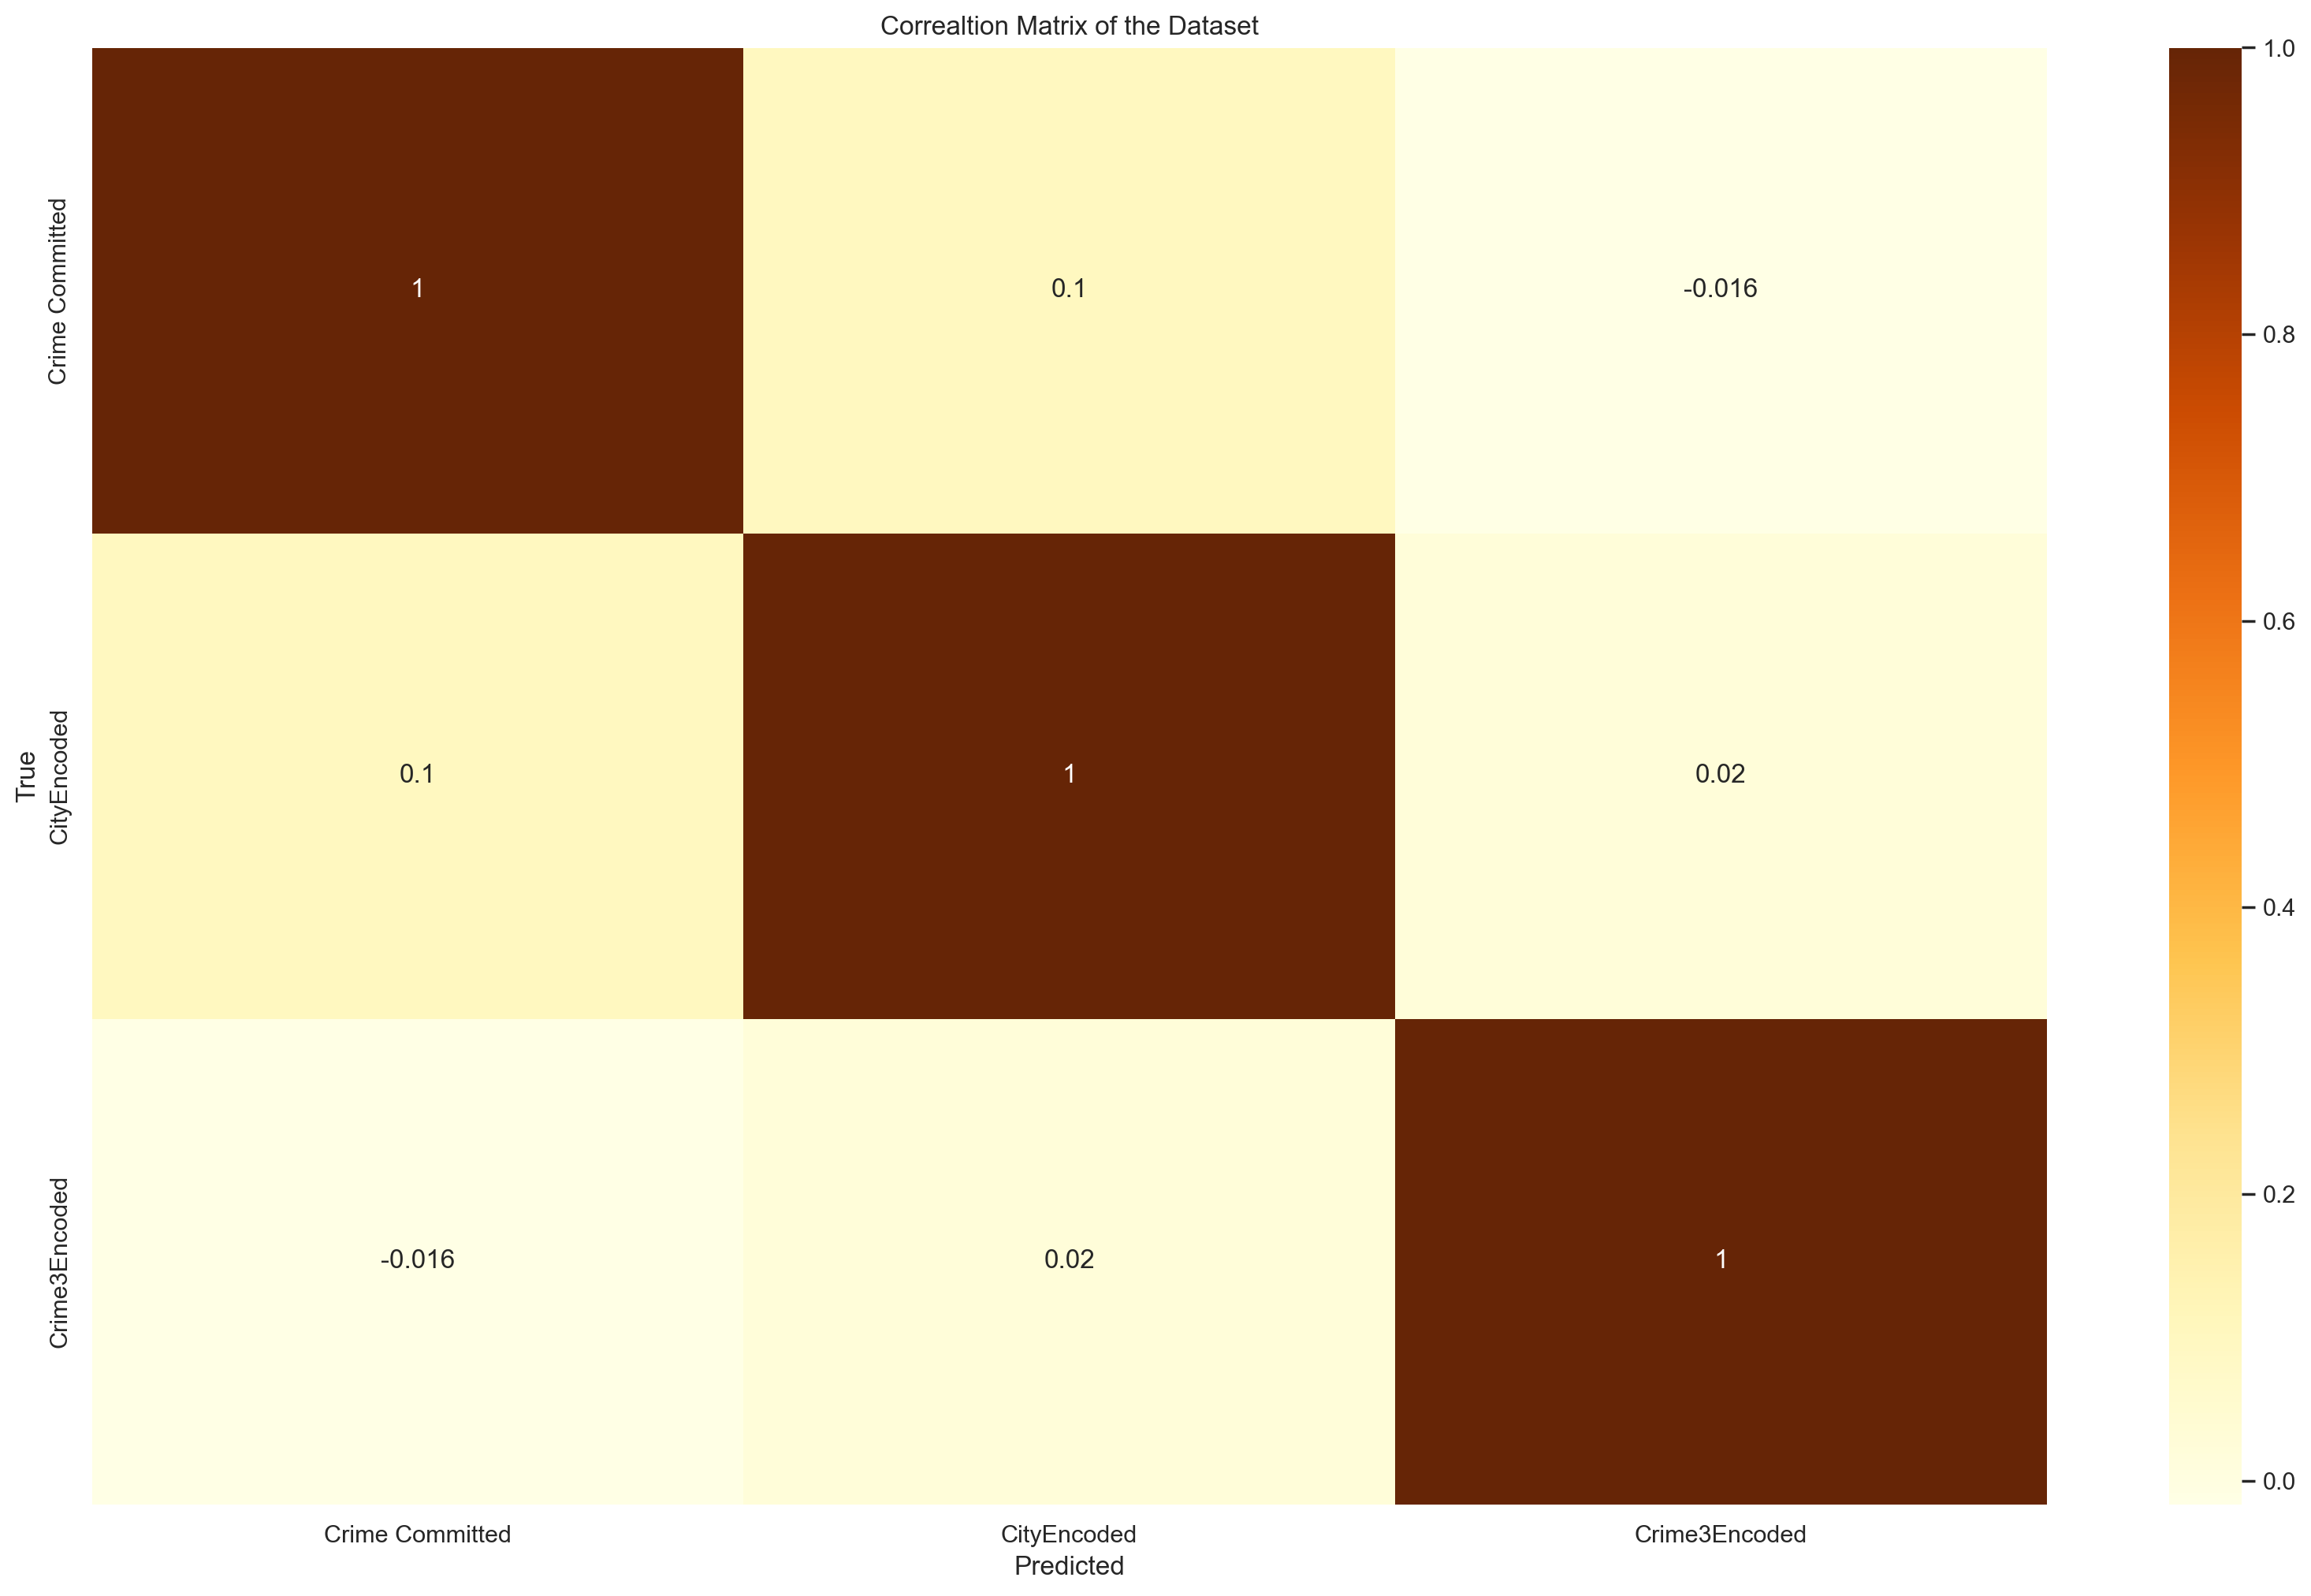

In [63]:
plt.figure( figsize = (20,12), dpi = 200)
sns.heatmap(corre_matrix, cmap='YlOrBr', annot= True);

plt.title('Correaltion Matrix of the Dataset');
plt.xlabel('Predicted');
plt.ylabel('True');

# Question 2:

#### What are the overall trends of crimes from 2018-2022 and how do these compare over the years? (Darren)

### I'm adding a new column called 'Year', which has the extracted year values from the 'Start_Date_Time' column

In [64]:
df['Year'] = df['Start_Date_Time'].dt.year

In [65]:
df.head(1)

,Offence Code,CR Number,Dispatch Date / Time,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,City,Zip Code,Place,Beat,Start_Date_Time,End_Date_Time,Latitude,Longitude,Year
Incident ID,,,,,,,,,,,,,,,,,
201309442,2299,200045066,2020-11-15 08:37:49,1,Crime Against Property,Burglary/Breaking and Entering,BURGLARY (DESCRIBE OFFENSE),ROCKVILLE,ROCKVILLE,20852,Commercial - Office Building,1A1,2020-11-14 23:00:00,2020-11-15 08:00:00,39.054614,-77.120109,2020


### There are many crimes different crimes committed in the County, so we will use the top ten crimes committed and see the trends throughout the years

In [66]:
topcrimes = df['Crime Name3'].value_counts().head(10).index
topcrimes

Index(['LARCENY - FROM AUTO', 'DAMAGE PROPERTY - PRIVATE',
       'LARCENY (DESCRIBE OFFENSE)', 'LARCENY - FROM BLDG',
       'LARCENY - AUTO PARTS', 'LARCENY - SHOPLIFTING', 'POLICE INFORMATION',
       'ASSAULT - 2ND DEGREE', 'LOST PROPERTY', 'AUTO THEFT - VEHICLE THEFT'],
      dtype='object', name='Crime Name3')

In [67]:
crimeyears_df = df[df['Crime Name3'].isin(topcrimes)]

#### Only the top ten crimes committed from Crime Name3 have been filtered into a new Data Frame called 'crimeyears_df'

In [68]:
crimeyears_df

,Offence Code,CR Number,Dispatch Date / Time,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,City,Zip Code,Place,Beat,Start_Date_Time,End_Date_Time,Latitude,Longitude,Year
Incident ID,,,,,,,,,,,,,,,,,
201367972,2308,220010707,2022-03-12 13:39:30,1,Crime Against Property,Theft from Building,LARCENY - FROM BLDG,BETHESDA,SILVER SPRING,20910,Residence - Apartment/Condo,2D1,2022-03-11 16:00:00,2022-03-12 13:00:00,38.995460,-77.042200,2022
201243815,2303,190028294,2019-06-13 17:05:28,1,Crime Against Property,Shoplifting,LARCENY - SHOPLIFTING,WHEATON,OLNEY,20832,Retail - Salon/Spa,4J2,2019-06-12 20:00:00,2019-06-12 21:15:00,39.151898,-77.062227,2019
201281270,2305,200011845,2020-03-10 18:26:46,1,Crime Against Property,Theft From Motor Vehicle,LARCENY - FROM AUTO,ROCKVILLE,ROCKVILLE,20850,Residence - Driveway,1A3,2020-03-06 03:20:00,2020-03-06 03:30:00,39.114433,-77.173918,2020
201273433,2902,200002130,2020-01-13 13:42:25,1,Crime Against Property,Destruction/Damage/Vandalism of Property,DAMAGE PROPERTY - PRIVATE,SILVER SPRING,SILVER SPRING,20910,Residence - Apartment/Condo,3G1,2020-01-10 15:00:00,2020-01-13 11:30:00,38.992602,-77.013197,2020
201294517,2304,200027224,2020-07-13 18:51:08,1,Crime Against Property,Theft of Motor Vehicle Parts or Accessories,LARCENY - AUTO PARTS,BETHESDA,BETHESDA,20814,Street - Residential,2D2,2020-07-05 18:00:00,2020-07-11 08:00:00,38.979589,-77.100918,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201203894,2399,180043315,2018-08-30 17:34:14,1,Crime Against Property,All other Larceny,LARCENY (DESCRIBE OFFENSE),ROCKVILLE,ROCKVILLE,20850,Residence - Yard,1A3,2018-08-29 19:30:00,2018-08-30 11:00:00,39.112142,-77.165298,2018
201314548,2305,200051191,2020-12-29 12:19:44,1,Crime Against Property,Theft From Motor Vehicle,LARCENY - FROM AUTO,WHEATON,SILVER SPRING,20902,Street - Residential,4L1,2020-12-29 00:01:00,2020-12-29 11:30:00,39.054776,-77.062038,2020
201213788,9199,180056047,2018-11-08 09:20:21,1,Other,All Other Offenses,POLICE INFORMATION,ROCKVILLE,ROCKVILLE,20850,School/College - DO NOT USE,1A3,2018-11-07 11:00:00,2018-11-07 11:10:00,39.078678,-77.161800,2018


In [69]:
crimeYearsTypes = crimeyears_df.groupby(['Year', 'Crime Name3'])
#crimeTypes = crimeyears_df.groupby('Crime Name3').sum()

In [70]:
crimeYearsTotal = crimeYearsTypes['Crime Name3'].count()

In [71]:
crimeYearsTotal = crimeYearsTotal.reset_index(name='Total Count')

In [72]:
crimeYearsTotal

,Year,Crime Name3,Total Count
0,2016,ASSAULT - 2ND DEGREE,1
1,2016,AUTO THEFT - VEHICLE THEFT,2
2,2016,DAMAGE PROPERTY - PRIVATE,4
3,2016,LARCENY (DESCRIBE OFFENSE),9
4,2016,LARCENY - AUTO PARTS,7
...,...,...,...
64,2022,LARCENY - FROM AUTO,782
65,2022,LARCENY - FROM BLDG,374
66,2022,LARCENY - SHOPLIFTING,297
67,2022,LOST PROPERTY,236


In [73]:
crimeyears_df = crimeyears_df.drop(crimeyears_df[crimeyears_df['Year'] == 2016].index)

In [74]:
crimeyears_df.head()

,Offence Code,CR Number,Dispatch Date / Time,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,City,Zip Code,Place,Beat,Start_Date_Time,End_Date_Time,Latitude,Longitude,Year
Incident ID,,,,,,,,,,,,,,,,,
201367972,2308,220010707,2022-03-12 13:39:30,1,Crime Against Property,Theft from Building,LARCENY - FROM BLDG,BETHESDA,SILVER SPRING,20910,Residence - Apartment/Condo,2D1,2022-03-11 16:00:00,2022-03-12 13:00:00,38.995460,-77.042200,2022
201243815,2303,190028294,2019-06-13 17:05:28,1,Crime Against Property,Shoplifting,LARCENY - SHOPLIFTING,WHEATON,OLNEY,20832,Retail - Salon/Spa,4J2,2019-06-12 20:00:00,2019-06-12 21:15:00,39.151898,-77.062227,2019
201281270,2305,200011845,2020-03-10 18:26:46,1,Crime Against Property,Theft From Motor Vehicle,LARCENY - FROM AUTO,ROCKVILLE,ROCKVILLE,20850,Residence - Driveway,1A3,2020-03-06 03:20:00,2020-03-06 03:30:00,39.114433,-77.173918,2020
201273433,2902,200002130,2020-01-13 13:42:25,1,Crime Against Property,Destruction/Damage/Vandalism of Property,DAMAGE PROPERTY - PRIVATE,SILVER SPRING,SILVER SPRING,20910,Residence - Apartment/Condo,3G1,2020-01-10 15:00:00,2020-01-13 11:30:00,38.992602,-77.013197,2020
201294517,2304,200027224,2020-07-13 18:51:08,1,Crime Against Property,Theft of Motor Vehicle Parts or Accessories,LARCENY - AUTO PARTS,BETHESDA,BETHESDA,20814,Street - Residential,2D2,2020-07-05 18:00:00,2020-07-11 08:00:00,38.979589,-77.100918,2020


In [75]:
crimeYearsTypes = crimeyears_df.groupby(['Year', 'Crime Name3'])

In [76]:
crimeYearsTotal = crimeYearsTypes['Crime Name3'].count()

In [77]:
crimeYearsTotal = crimeYearsTotal.reset_index(name = 'Total Count')

In [78]:
crimeYearsTotal.head()

,Year,Crime Name3,Total Count
0,2017,ASSAULT - 2ND DEGREE,561
1,2017,AUTO THEFT - VEHICLE THEFT,344
2,2017,DAMAGE PROPERTY - PRIVATE,835
3,2017,LARCENY (DESCRIBE OFFENSE),886
4,2017,LARCENY - AUTO PARTS,406


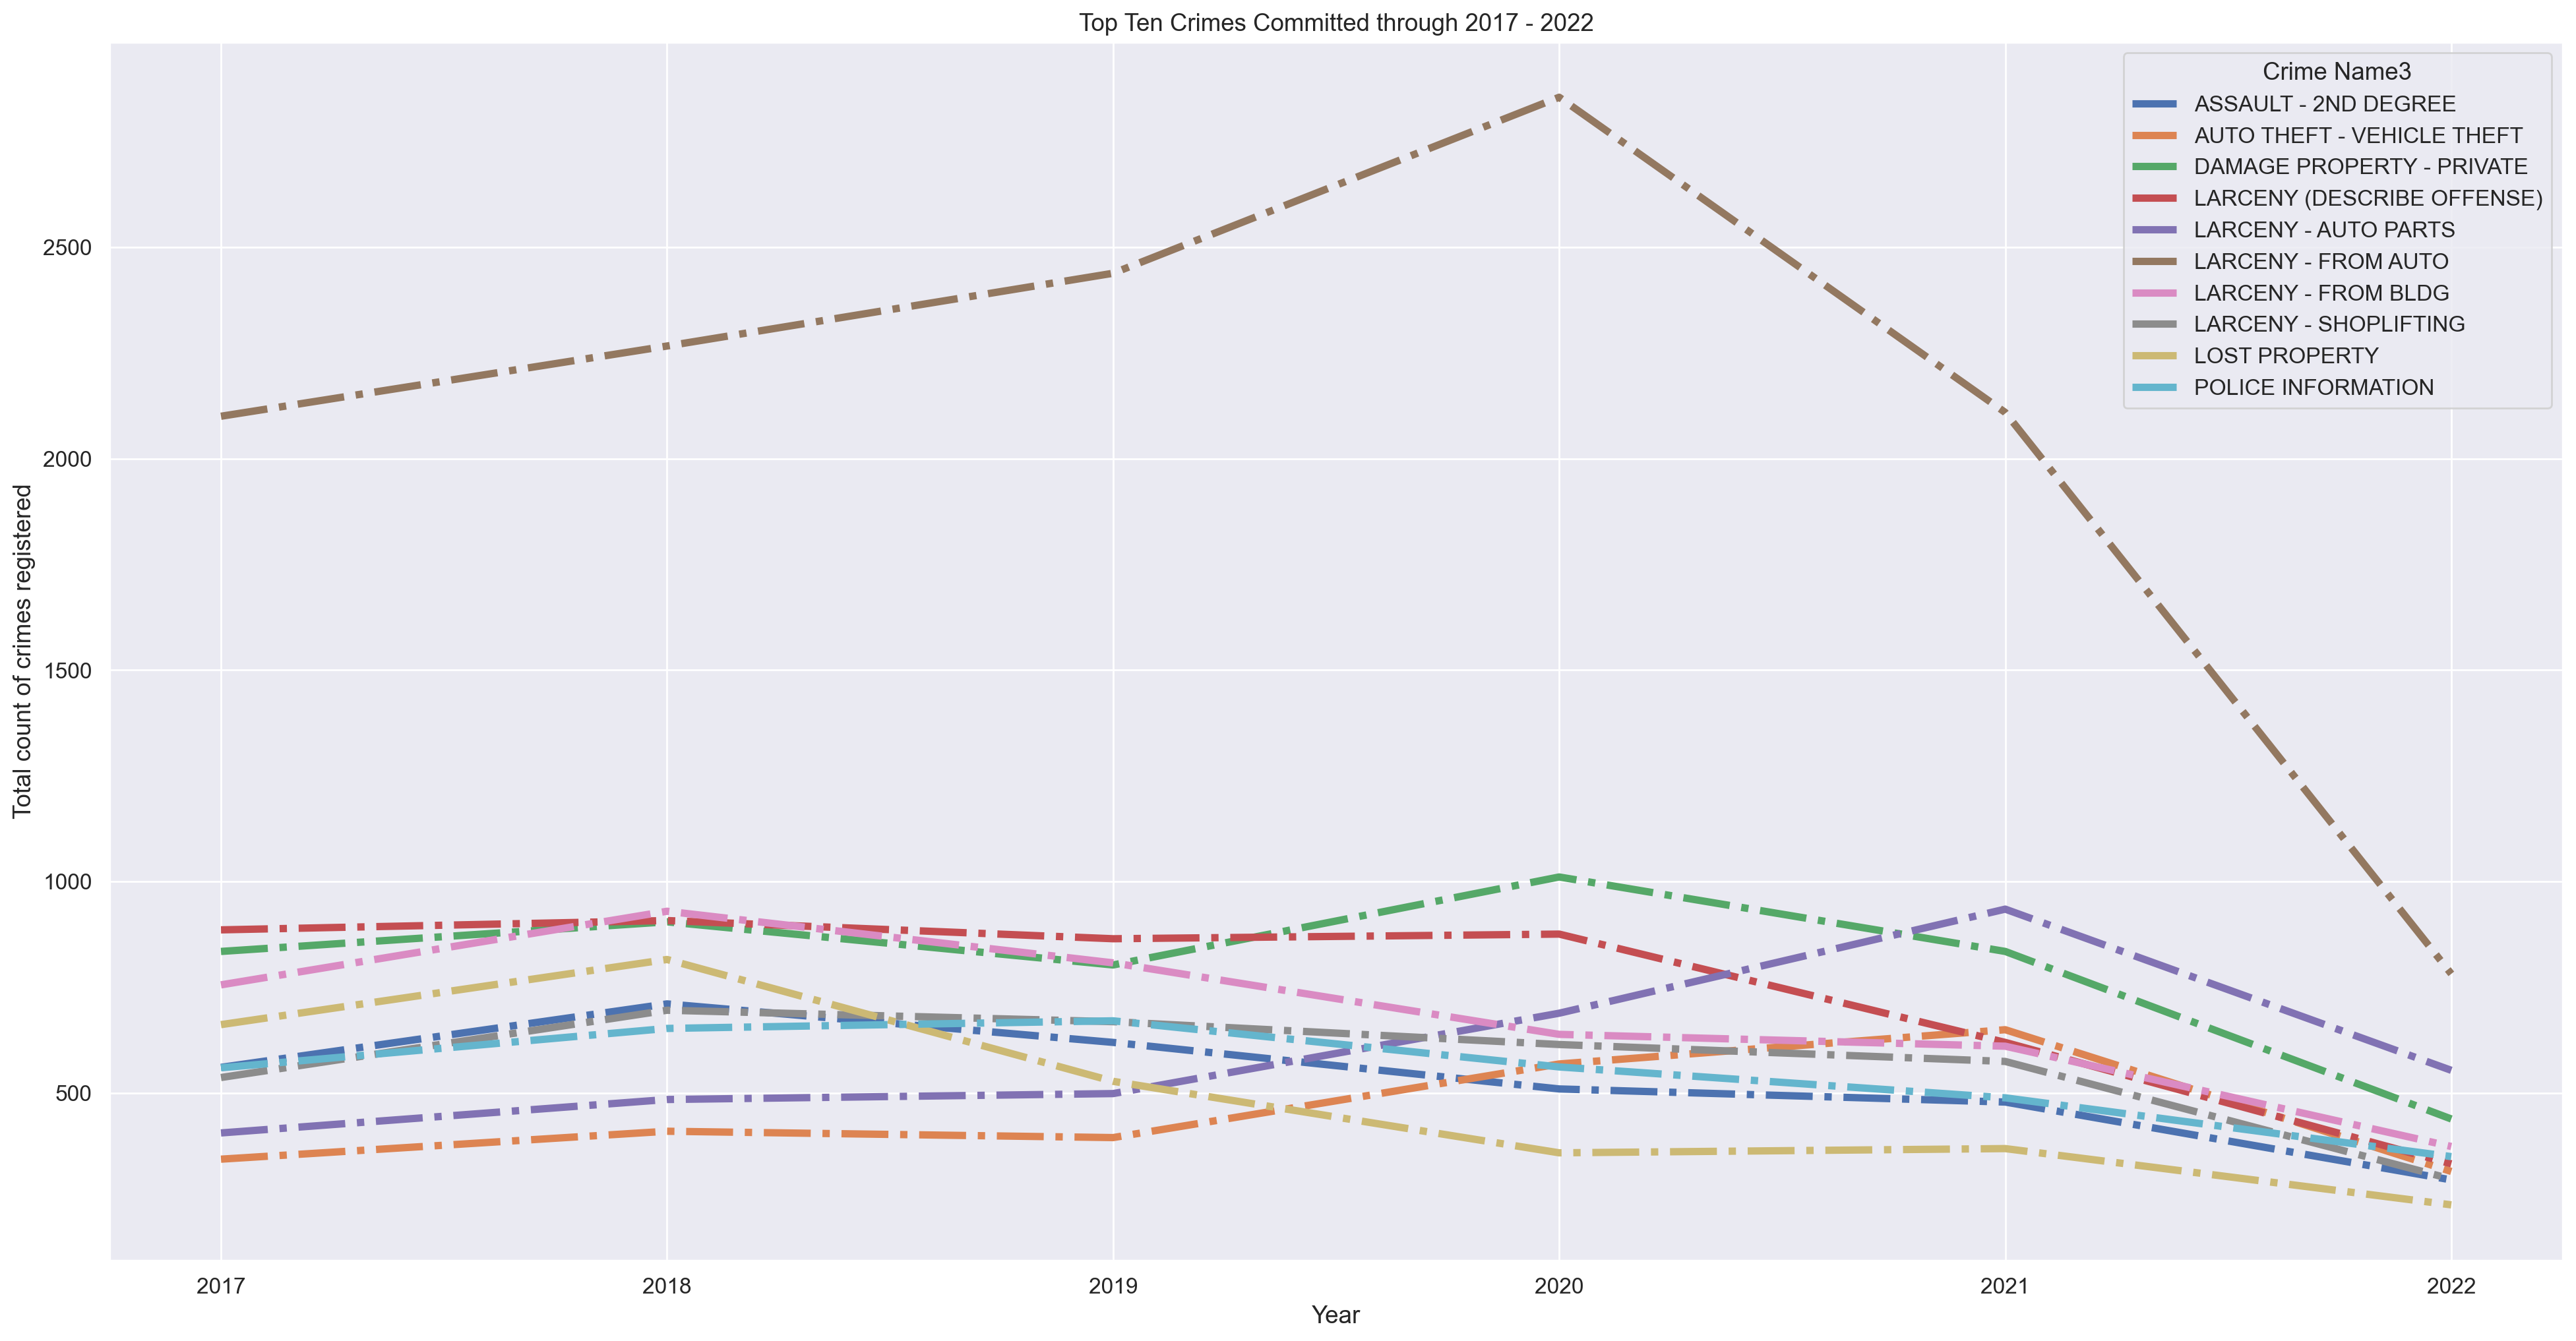

In [79]:
plt.figure(figsize = (24,12), dpi = 200);

sns.set_context('notebook', font_scale=1.1)
sns.lineplot(data = crimeYearsTotal, x = 'Year', y = 'Total Count', hue = 'Crime Name3', linestyle = 'dashdot', linewidth = 4).set(
    title = 'Top Ten Crimes Committed through 2017 - 2022',
    xlabel = 'Year',
    ylabel = 'Total count of crimes registered'
);


#### Line-style arg: 'solid', 'dashed', 'dotted', 'dashdot'


In [80]:
### Create a graph that splits the count into months each year for comparisons. maybe use catplot, stripplot, or FacetGrid

### Or use a piechart to help demonstrate 

In [81]:
crimemonths_df = crimeyears_df

In [82]:
crimemonths_df['MonYear'] = crimemonths_df['Start_Date_Time'].dt.strftime('%b-%Y')

In [83]:
crimeMonthTypes = crimeyears_df.groupby(['MonYear', 'Crime Name3'])

In [84]:
crimeMonthTotal = crimeMonthTypes['Crime Name3'].count()

In [85]:
crimeMonthTotal = crimeMonthTotal.reset_index(name = 'Total Count')

In [86]:
crimeMonthTotal.head()

,MonYear,Crime Name3,Total Count
0,Apr-2017,ASSAULT - 2ND DEGREE,36
1,Apr-2017,AUTO THEFT - VEHICLE THEFT,38
2,Apr-2017,DAMAGE PROPERTY - PRIVATE,93
3,Apr-2017,LARCENY (DESCRIBE OFFENSE),75
4,Apr-2017,LARCENY - AUTO PARTS,37


# Question 3:

#### If the number of crimes and the avg response time correlate


In [87]:
# Making a coopy of the df 

avg_df = df.copy()
avg_df.head(3)

,Offence Code,CR Number,Dispatch Date / Time,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,City,Zip Code,Place,Beat,Start_Date_Time,End_Date_Time,Latitude,Longitude,Year
Incident ID,,,,,,,,,,,,,,,,,
201309442,2299,200045066,2020-11-15 08:37:49,1,Crime Against Property,Burglary/Breaking and Entering,BURGLARY (DESCRIBE OFFENSE),ROCKVILLE,ROCKVILLE,20852,Commercial - Office Building,1A1,2020-11-14 23:00:00,2020-11-15 08:00:00,39.054614,-77.120109,2020
201367972,2308,220010707,2022-03-12 13:39:30,1,Crime Against Property,Theft from Building,LARCENY - FROM BLDG,BETHESDA,SILVER SPRING,20910,Residence - Apartment/Condo,2D1,2022-03-11 16:00:00,2022-03-12 13:00:00,38.995460,-77.042200,2022
201243815,2303,190028294,2019-06-13 17:05:28,1,Crime Against Property,Shoplifting,LARCENY - SHOPLIFTING,WHEATON,OLNEY,20832,Retail - Salon/Spa,4J2,2019-06-12 20:00:00,2019-06-12 21:15:00,39.151898,-77.062227,2019


In [88]:
# Adding a column that contains the time difference between the dispatch time and the start time by minutes

avg_df['Time_diff'] = (avg_df['Dispatch Date / Time'] - avg_df['Start_Date_Time']).dt.total_seconds() / 60
avg_df['Time_diff'] = avg_df['Time_diff'].round(2)
avg_df.head(1)

,Offence Code,CR Number,Dispatch Date / Time,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,City,Zip Code,Place,Beat,Start_Date_Time,End_Date_Time,Latitude,Longitude,Year,Time_diff
Incident ID,,,,,,,,,,,,,,,,,,
201309442,2299,200045066,2020-11-15 08:37:49,1,Crime Against Property,Burglary/Breaking and Entering,BURGLARY (DESCRIBE OFFENSE),ROCKVILLE,ROCKVILLE,20852,Commercial - Office Building,1A1,2020-11-14 23:00:00,2020-11-15 08:00:00,39.054614,-77.120109,2020,577.82


In [89]:
sum_avg = avg_df[avg_df['Time_diff'] == 0]

print(f'Value count of time diff with 0 minutes: {sum_avg.shape[0]}')

print(f'Maximum value: {avg_df['Time_diff'].max()}')

Value count of time diff with 0 minutes: 246
Maximum value: 2913120.07


In [90]:
# Filtering for realistic emergency response (e.g., under 120 minutes)
# This removes the 1000-day gaps that may skewer the data 
realistic_response = avg_df[(avg_df['Time_diff'] > 0) & (avg_df['Time_diff'] < 120)]

# Now grouping the filtered data
avg_response = realistic_response.groupby('City')['Time_diff'].mean().sort_values()
avg_response

City
BELTSVILLE             0.120000
LAUREL                 0.230000
WOODBINE               0.400000
MOUNT AIRY             0.420000
BARNESVILLE            1.670000
WASHINGTON GROVE       8.730000
BRINKLOW              10.826667
TAKOMA PARK           12.925217
GLEN ECHO             13.458889
ROCKVILLE             15.220971
SILVER SPRING         15.383694
MONTGOMERY VILLAGE    16.223089
BROOKEVILLE           17.106364
BURTONSVILLE          17.696691
DICKERSON             18.073077
GERMANTOWN            18.285072
KENSINGTON            18.437354
DERWOOD               19.277045
DAMASCUS              20.187798
SPENCERVILLE          20.710000
OLNEY                 21.725938
GAITHERSBURG          21.961605
POTOMAC               22.910826
CLARKSBURG            25.778235
BETHESDA              27.267305
BOYDS                 27.413896
SANDY SPRING          27.963600
CABIN JOHN            29.915238
POOLESVILLE           30.089318
CHEVY CHASE           30.455211
ASHTON                31.679630
BEA

In [91]:
crimeTotal = avg_df['City'].value_counts()
avgResponse_df = pd.DataFrame({'Average Response Time Mins': avg_response, 'Number of Crimes': crimeTotal})

In [92]:
avgResponse_df.sort_values('Average Response Time Mins')

,Average Response Time Mins,Number of Crimes
City,,
BELTSVILLE,0.120000,2
LAUREL,0.230000,12
WOODBINE,0.400000,2
MOUNT AIRY,0.420000,11
BARNESVILLE,1.670000,5
WASHINGTON GROVE,8.730000,3
BRINKLOW,10.826667,26
TAKOMA PARK,12.925217,2716
GLEN ECHO,13.458889,34


In [93]:
avgResponse_df = avgResponse_df.dropna(subset='Average Response Time Mins')

In [94]:
avgResponse_df

,Average Response Time Mins,Number of Crimes
City,,
ASHTON,31.679630,85
BARNESVILLE,1.670000,5
BEALLSVILLE,65.248000,13
BELTSVILLE,0.120000,2
BETHESDA,27.267305,6100
BOYDS,27.413896,402
BRINKLOW,10.826667,26
BROOKEVILLE,17.106364,268
BURTONSVILLE,17.696691,1024


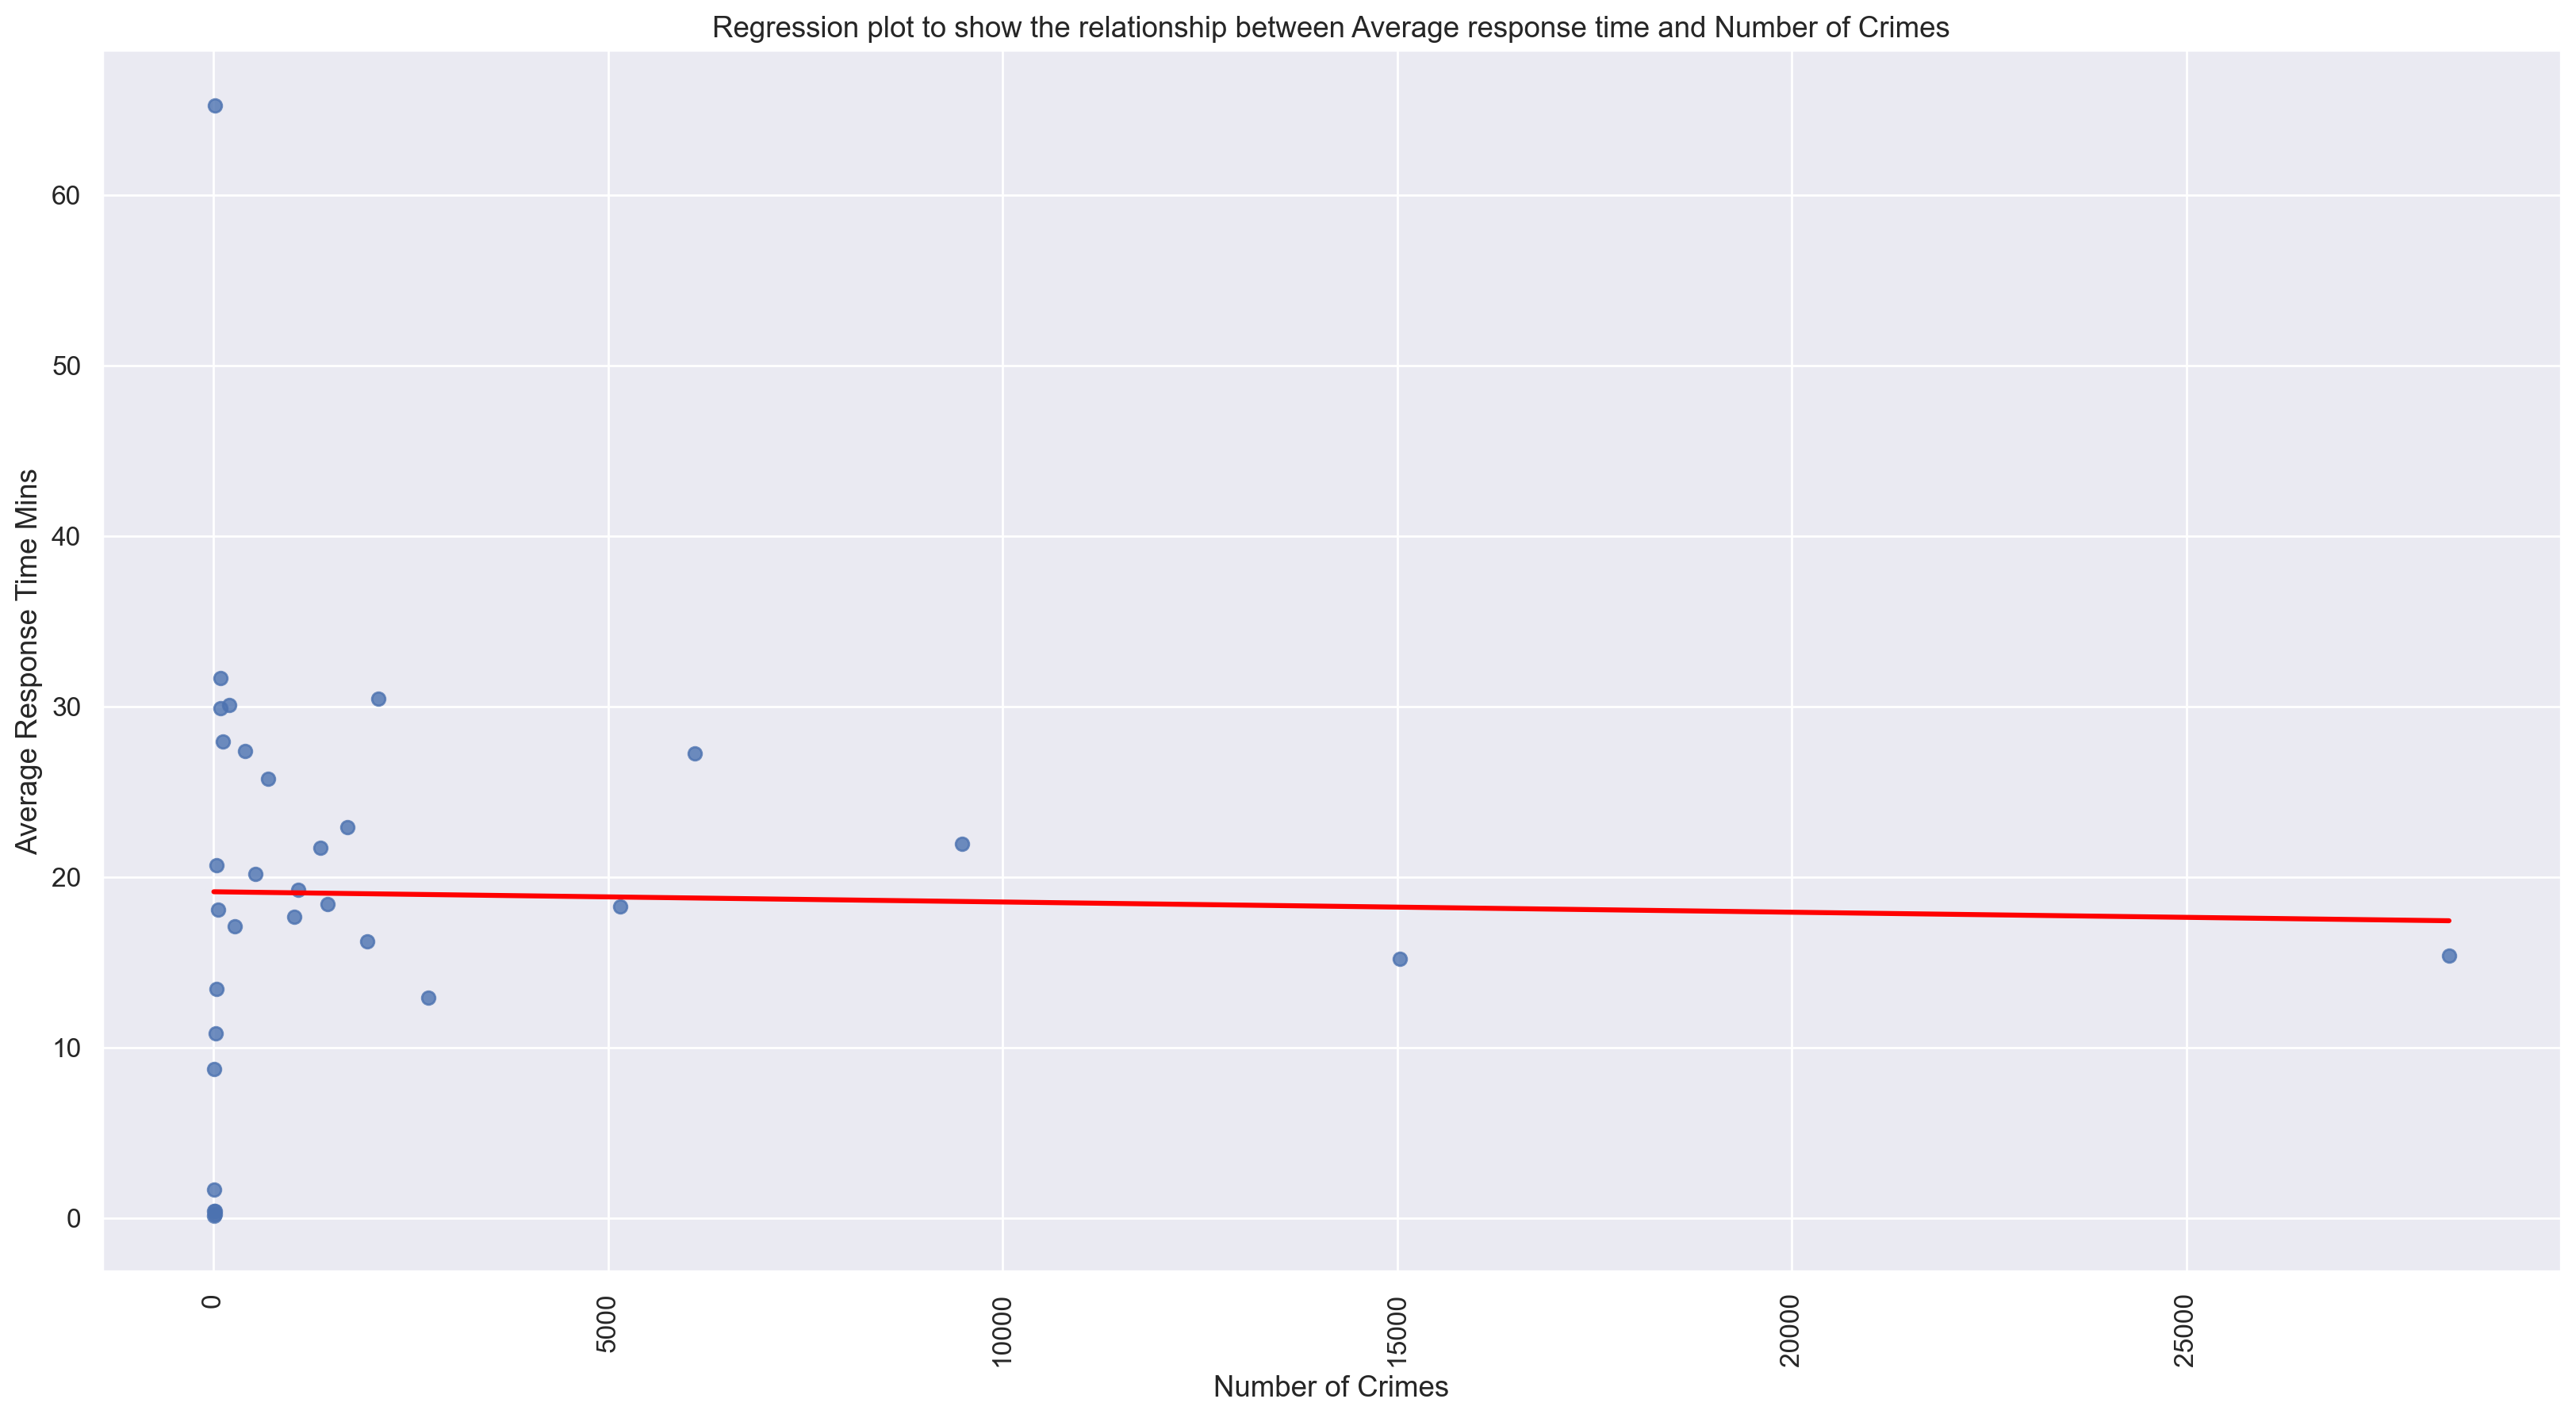

In [95]:
plt.figure(figsize = (20,10), dpi = 200);

sns.regplot(data = avgResponse_df, x = 'Number of Crimes', y = 'Average Response Time Mins', line_kws={'color': 'red'},
            ci = None).grid(True);
plt.xticks(rotation = 90);
plt.title('Regression plot to show the relationship between Average response time and Number of Crimes');

In [96]:
# Removing the outlier from the graph 

avgResponse_df = avgResponse_df[avgResponse_df['Average Response Time Mins'] <= 60]

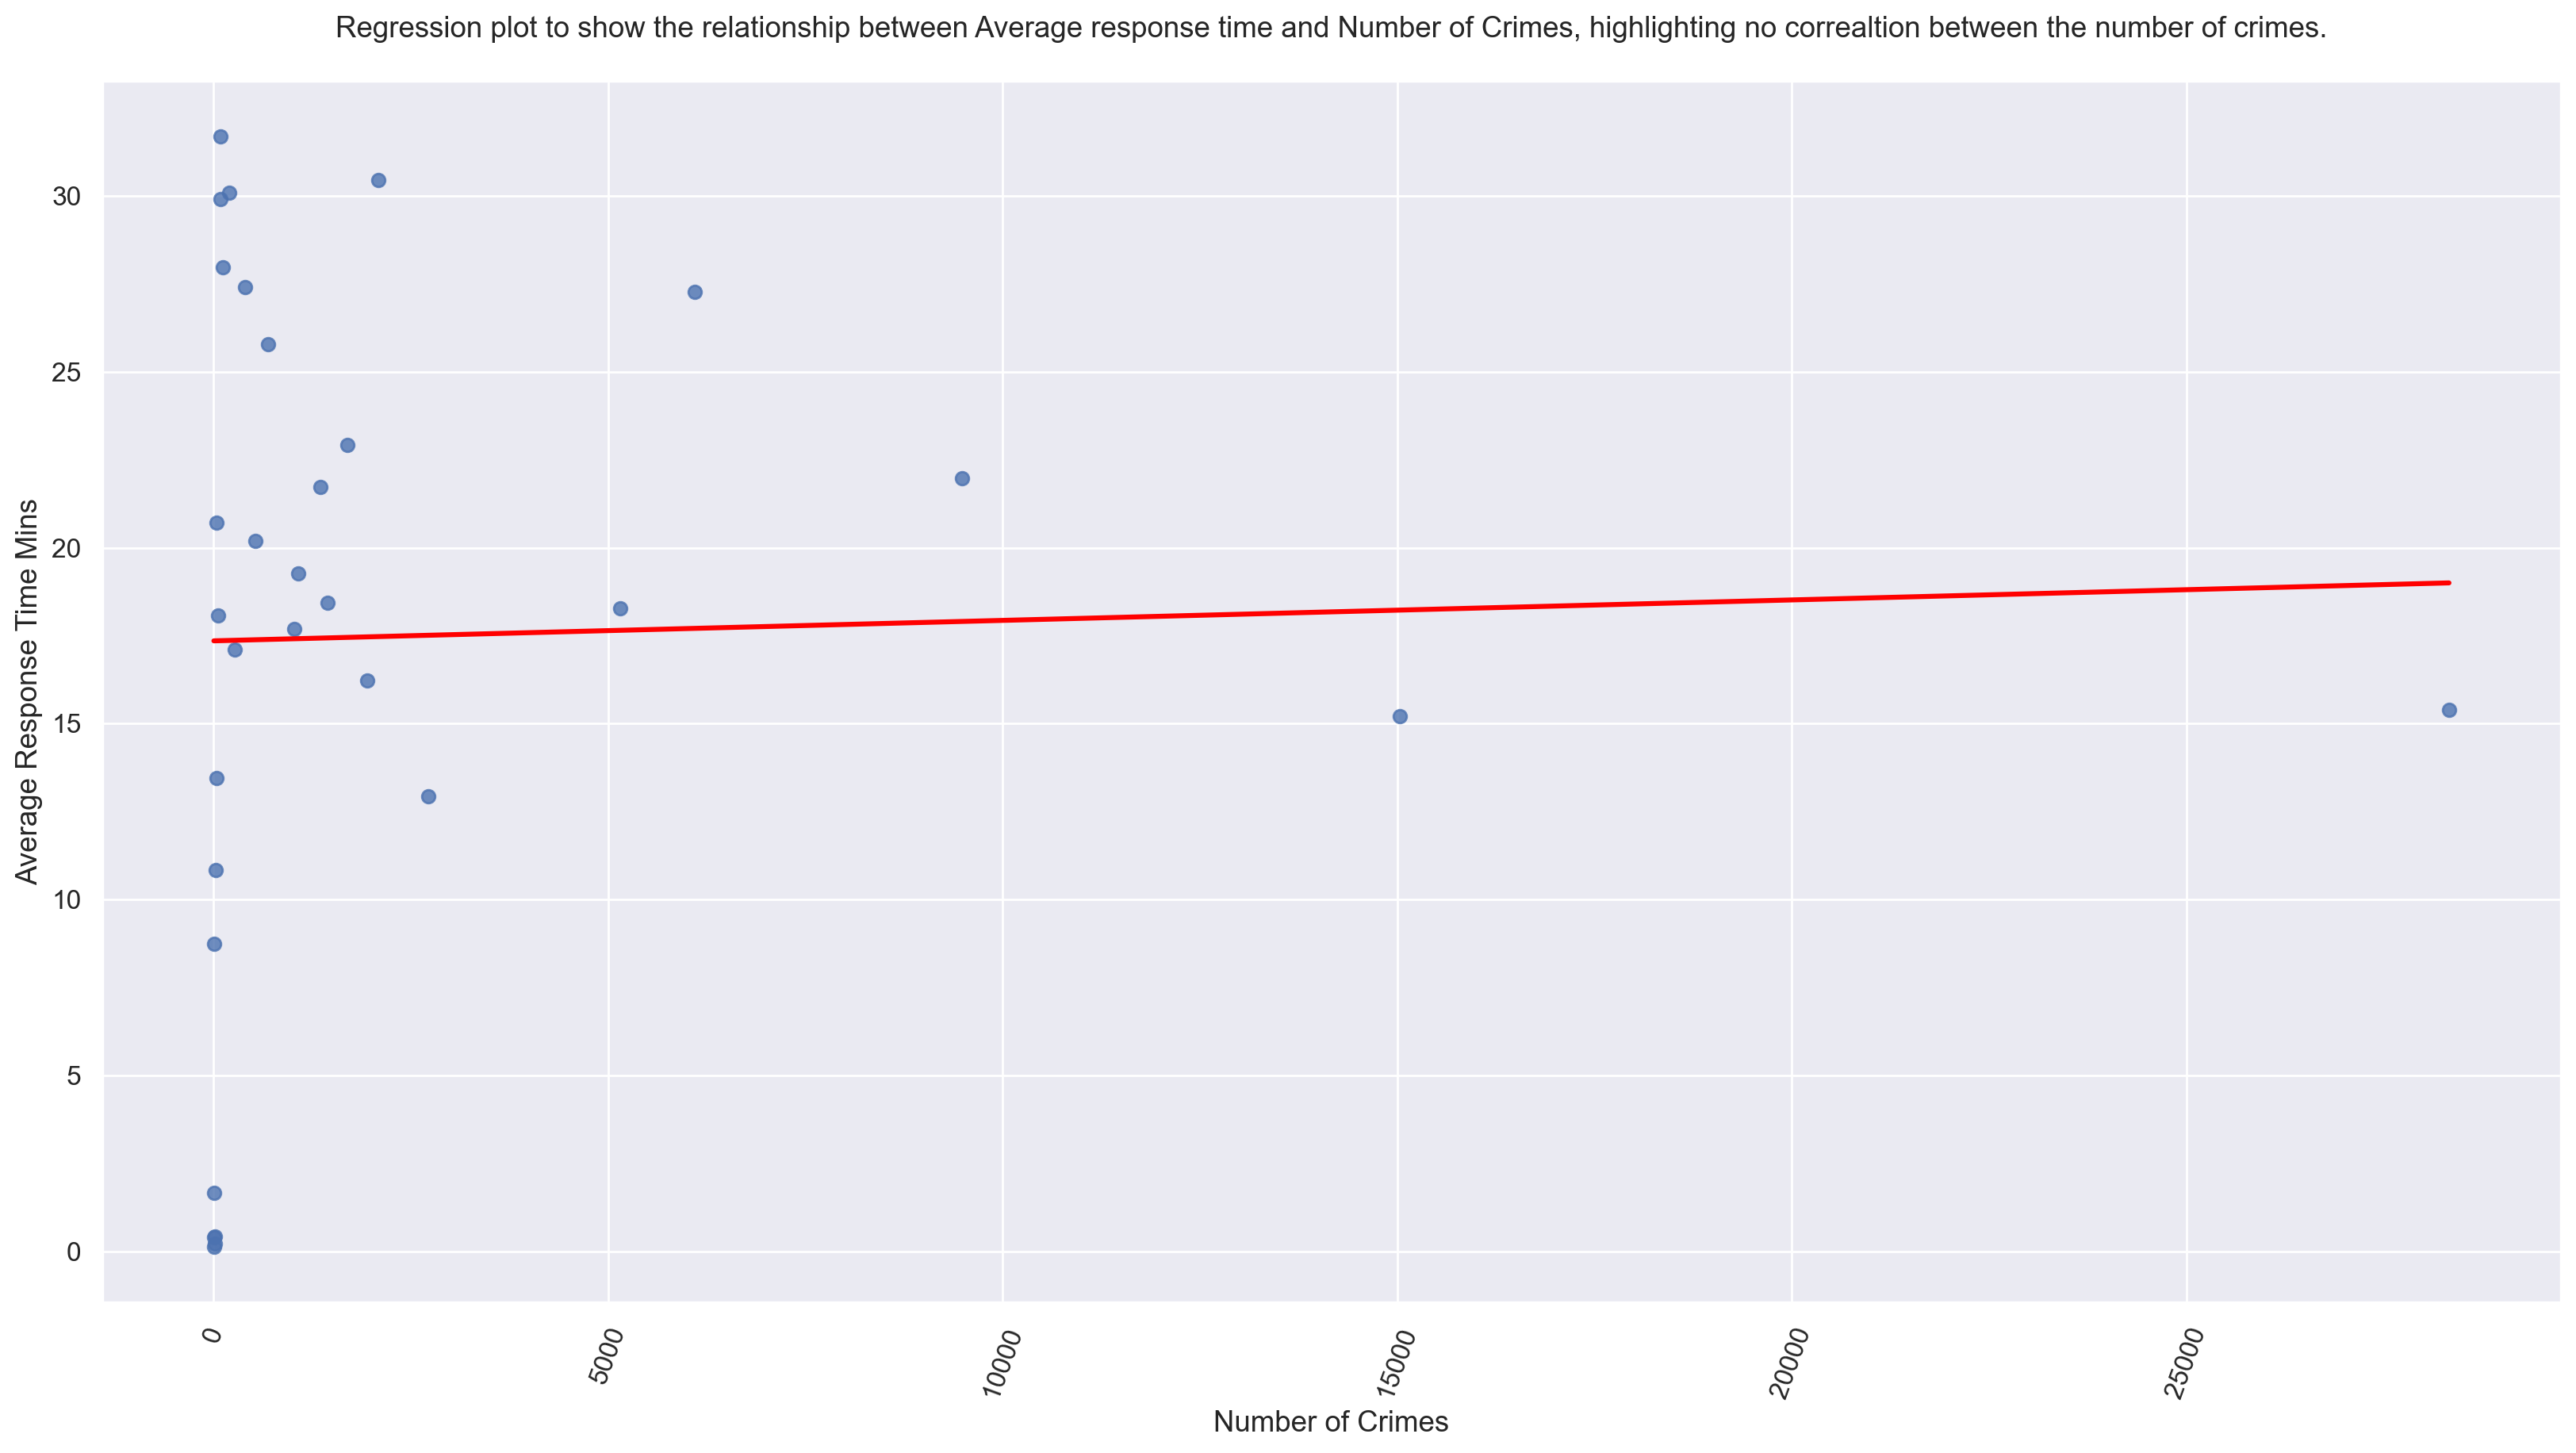

In [97]:
plt.figure(figsize = (20,10), dpi = 200);

sns.regplot(data = avgResponse_df, x = 'Number of Crimes', y = 'Average Response Time Mins', line_kws={'color': 'red'},
            ci = None).grid(True);
plt.xticks(rotation = 70);
plt.title('Regression plot to show the relationship between Average response time and Number of Crimes, highlighting no correaltion between the number of crimes.', pad= 20);

# Question 4

### Top Ten cities with the highest crime rates?

In [98]:
### Sum total of crimes in Crime Name 1 Column 

df['Crime Name1'].value_counts()

Crime Name1
Crime Against Property    48859
Other                     13099
Crime Against Society     11427
Crime Against Person       5921
Not a Crime                 623
Not Specified                71
Name: count, dtype: int64

In [99]:
### Sum total of crimes in Crime Name 2 Column 

df['Crime Name2'].value_counts().head(20)

Crime Name2
All Other Offenses                             14994
Theft From Motor Vehicle                       12550
Destruction/Damage/Vandalism of Property        7036
All other Larceny                               5094
Theft from Building                             4232
Simple Assault                                  3995
Theft of Motor Vehicle Parts or Accessories     3578
Drug/Narcotic Violations                        3560
Shoplifting                                     3389
Burglary/Breaking and Entering                  3027
Motor Vehicle Theft                             2772
Driving Under the Influence                     2104
Identity Theft                                  1552
Credit Card/Automatic Teller Machine Fraud      1506
False Pretenses/Swindle/Confidence Game         1389
Liquor Law Violations                           1129
Counterfeiting/Forgery                           910
Disorderly Conduct                               902
Trespass of Real Property         

In [100]:
### Sum total of crimes in Crime Name 3 Column 

df['Crime Name3'].value_counts().head(20)

Crime Name3
LARCENY - FROM AUTO                    12550
DAMAGE PROPERTY - PRIVATE               4832
LARCENY (DESCRIBE OFFENSE)              4497
LARCENY - FROM BLDG                     4125
LARCENY - AUTO PARTS                    3575
LARCENY - SHOPLIFTING                   3389
POLICE INFORMATION                      3289
ASSAULT - 2ND DEGREE                    3177
LOST PROPERTY                           2986
AUTO THEFT - VEHICLE THEFT              2685
DRUGS - MARIJUANA - POSSESS             2422
MENTAL ILLNESS - EMERGENCY PETITION     2359
DRIVING UNDER THE INFLUENCE LIQUOR      2005
SUDDEN DEATH                            1610
IDENTITY THEFT                          1552
FRAUD - ILLEGAL USE CREDIT CARDS        1506
DAMAGE PROPERTY (DESCRIBE OFFENSE)      1227
BURGLARY - FORCED ENTRY-RESIDENTIAL     1095
MISSING PERSON                          1016
PUBLIC PEACE - DISORDERLY CONDUCT        869
Name: count, dtype: int64

In [101]:
### Exploring crimes in the from all other offenses in Crime Name2 column 

df_otherCrime = df[df['Crime Name2'] == 'All Other Offenses']
df_otherCrime['Crime Name3'].unique()

array(['LOST PROPERTY', 'MENTAL ILLNESS - EMERGENCY PETITION',
       'SUDDEN DEATH', 'OVERDOSE',
       'PUBLIC PEACE - HARASSING COMMUNICATION', 'POLICE INFORMATION',
       'RECOVERED PROPERTY - MONT CO.', 'RECOVERED PROPERTY - OTHER',
       'SEX OFFENSE - INDECENT EXPOSURE TO ADULT', 'ALL OTHER OFFENSES',
       'MISSING PERSON', 'MENTAL ILLNESS', 'SUICIDE - ATTEMPT',
       'OBSTRUCT POLICE - OBSTRUCT CRIMINAL INVEST',
       'MENTAL TRANSPORT - ONLY',
       'UNAUTHORIZED USE OF VEHICLE (INCLUDES JOY RIDING)',
       'FUGITIVE FROM JUSTICE (OUT OF STATE)',
       'SEX OFFENSE - INDECENT EXPOSURE',
       'OBSTRUCT POLICE - RESISTING OFFICER',
       'OBSTRUCT GOVT - VIOLATION OF A COURT ORDER',
       'FALSE IMPRISONMENT - MINOR - NONPARENTAL',
       'LITTERING/TRASH DUMPING', 'OBSTRUCT POLICE (DESCRIBE OFFENSE)',
       'FUGITIVE FROM MD JURISDICTION',
       'COMM SEX OFF - PROCURE PROSTITUTE - MINOR', 'SUICIDE - COMPLETED',
       'JUVENILE - OTHER', 'FIRE (NOT ARSON)',
    

In [102]:
topcity = df['City'].value_counts().head(10).index
topcity

Index(['SILVER SPRING', 'ROCKVILLE', 'GAITHERSBURG', 'BETHESDA', 'GERMANTOWN',
       'TAKOMA PARK', 'CHEVY CHASE', 'MONTGOMERY VILLAGE', 'POTOMAC',
       'KENSINGTON'],
      dtype='object', name='City')

In [103]:
topcity_df = df[df['City'].isin(topcity)]
topcity_df.head()

,Offence Code,CR Number,Dispatch Date / Time,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,City,Zip Code,Place,Beat,Start_Date_Time,End_Date_Time,Latitude,Longitude,Year
Incident ID,,,,,,,,,,,,,,,,,
201309442,2299,200045066,2020-11-15 08:37:49,1,Crime Against Property,Burglary/Breaking and Entering,BURGLARY (DESCRIBE OFFENSE),ROCKVILLE,ROCKVILLE,20852,Commercial - Office Building,1A1,2020-11-14 23:00:00,2020-11-15 08:00:00,39.054614,-77.120109,2020
201367972,2308,220010707,2022-03-12 13:39:30,1,Crime Against Property,Theft from Building,LARCENY - FROM BLDG,BETHESDA,SILVER SPRING,20910,Residence - Apartment/Condo,2D1,2022-03-11 16:00:00,2022-03-12 13:00:00,38.995460,-77.042200,2022
201281270,2305,200011845,2020-03-10 18:26:46,1,Crime Against Property,Theft From Motor Vehicle,LARCENY - FROM AUTO,ROCKVILLE,ROCKVILLE,20850,Residence - Driveway,1A3,2020-03-06 03:20:00,2020-03-06 03:30:00,39.114433,-77.173918,2020
201273433,2902,200002130,2020-01-13 13:42:25,1,Crime Against Property,Destruction/Damage/Vandalism of Property,DAMAGE PROPERTY - PRIVATE,SILVER SPRING,SILVER SPRING,20910,Residence - Apartment/Condo,3G1,2020-01-10 15:00:00,2020-01-13 11:30:00,38.992602,-77.013197,2020
201203318,3562,180042476,2018-08-26 09:39:39,1,Crime Against Society,Drug/Narcotic Violations,DRUGS - MARIJUANA - POSSESS,WHEATON,SILVER SPRING,20905,Street - In vehicle,4J1,2018-08-26 09:41:00,2018-08-27 00:00:00,39.118887,-77.021196,2018


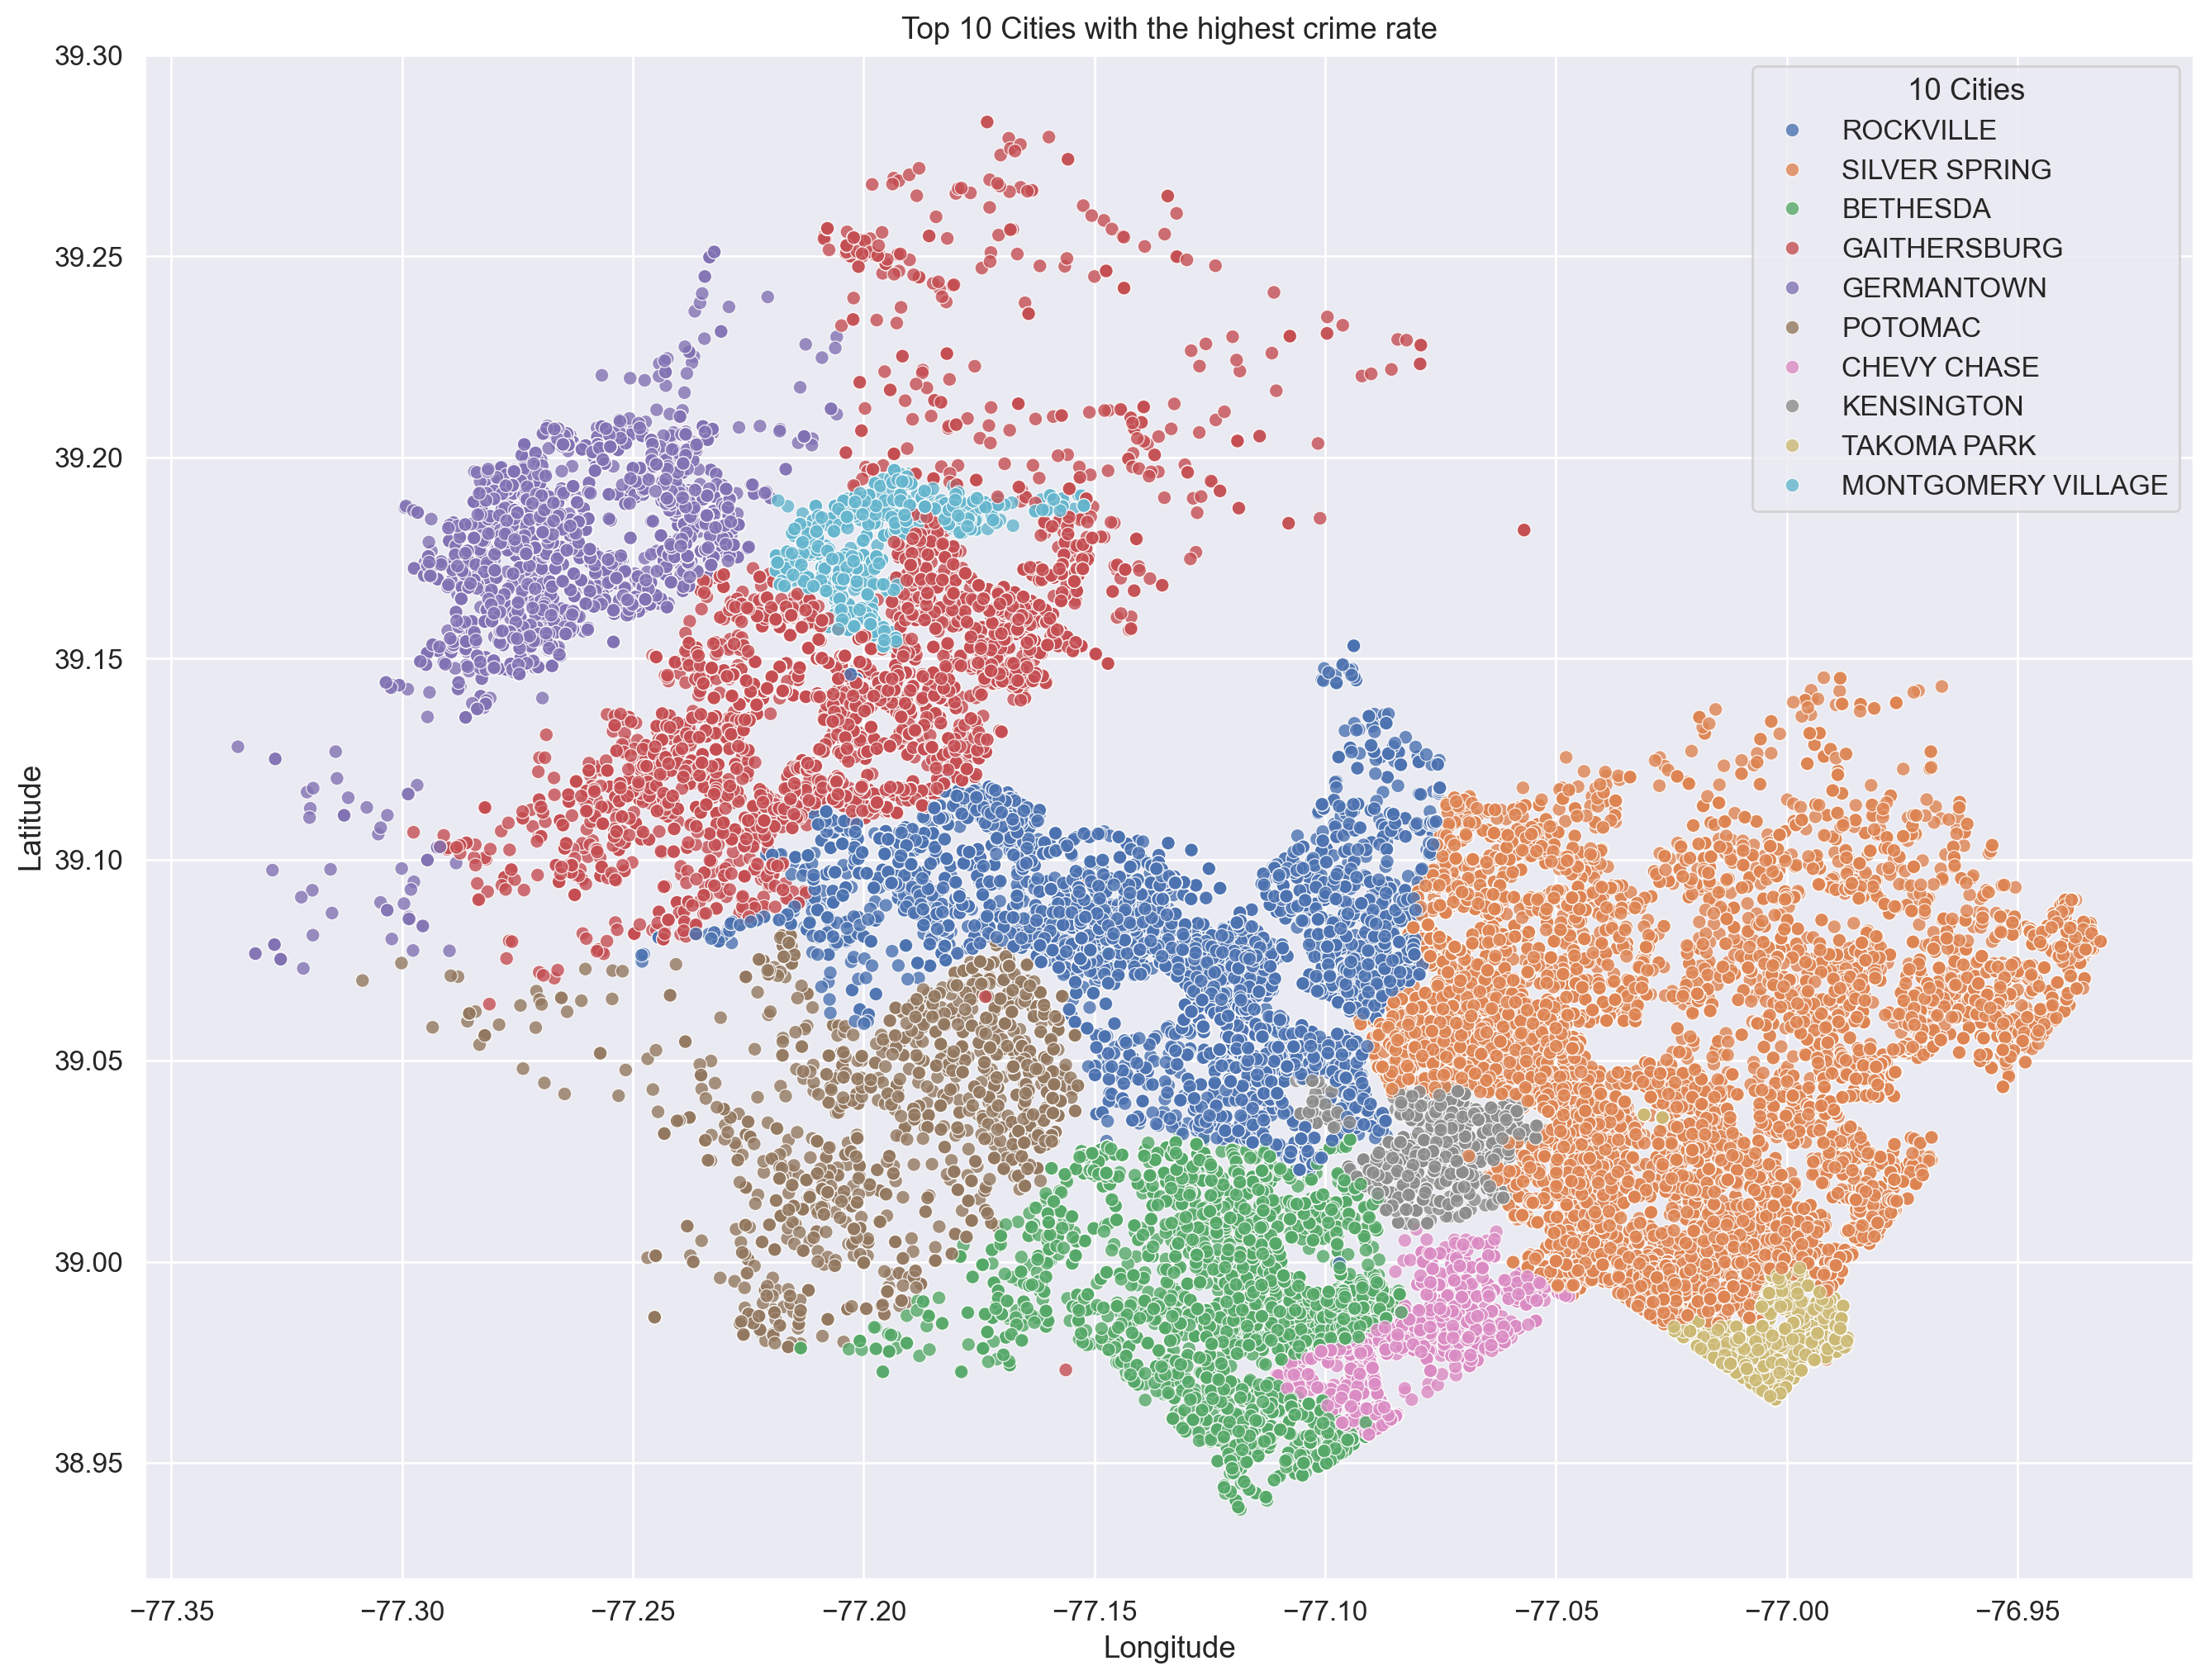

In [104]:
plt.figure(figsize = (16,12), dpi = 200)


sns.scatterplot(data = topcity_df, x='Longitude', y='Latitude', hue = 'City', alpha = 0.8).set(
    title = 'Top 10 Cities with the highest crime rate',);


plt.title('Top 10 Cities with the highest crime rate');
plt.legend(title = '10 Cities');

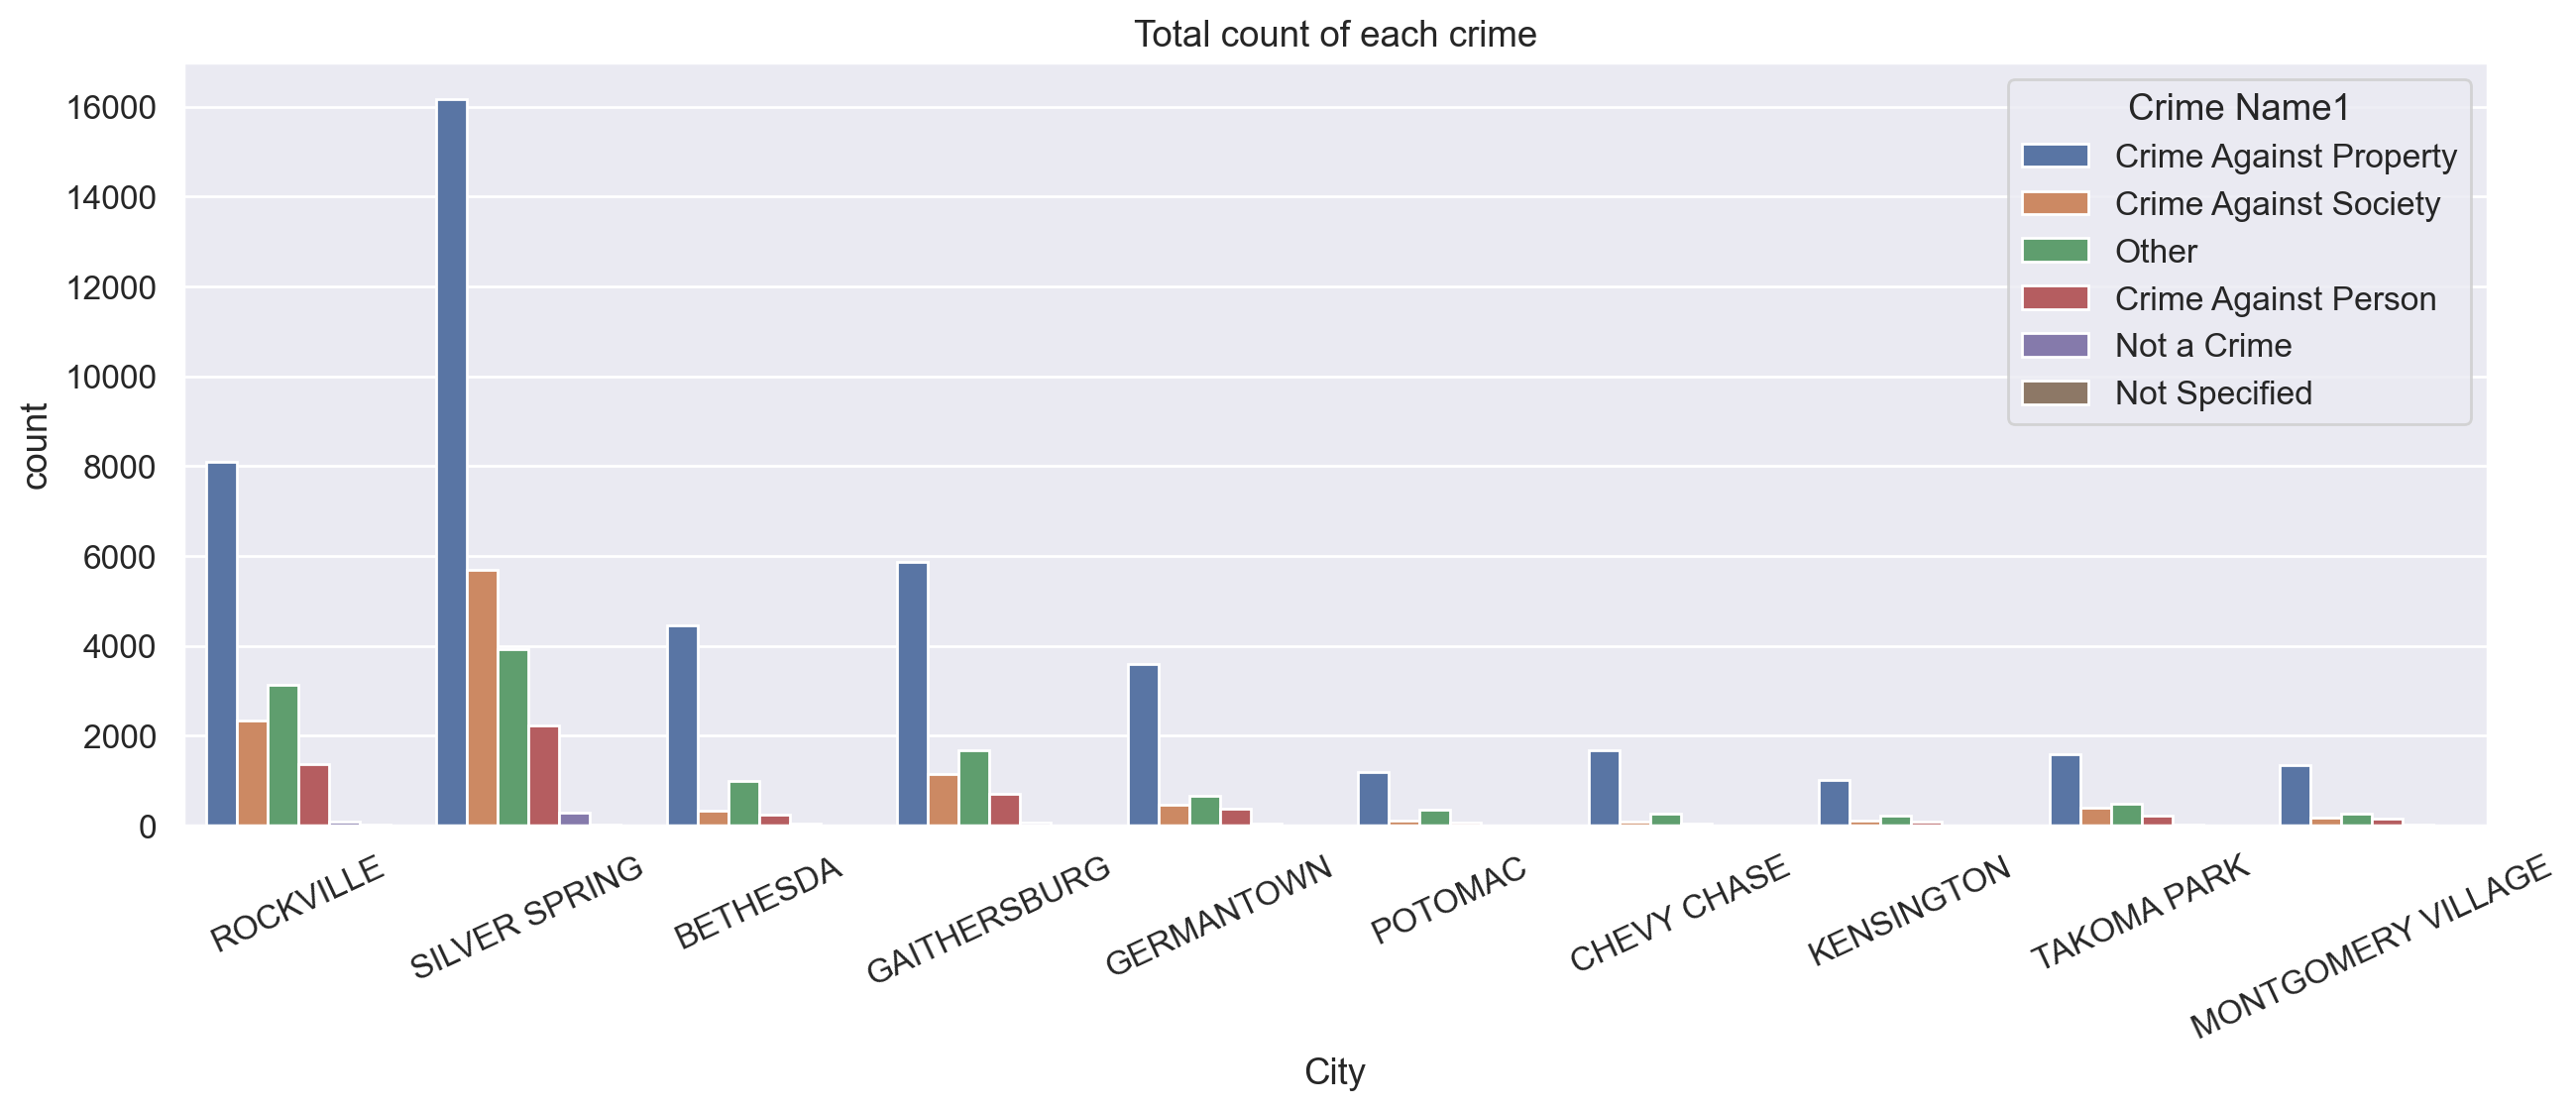

In [105]:
plt.figure(figsize = (15,5), dpi = 200);

sns.countplot(topcity_df, x = 'City', hue = 'Crime Name1');
plt.title('Total count of each crime');
plt.xticks(rotation = 25);
# plt.legend(labels = ['Alive', 'Dead']);